## 
    Time period	: 1950 - 2023
    
    location:   s(glost,k=5)  
    
    scale	    s(glost,k=5)
    shape       1



In [1]:
itest='loc_sc_loess'

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy

In [3]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv
pandas2ri.activate()

extRemes = importr("extRemes")
evgam = importr("evgam")
reticulate = importr("reticulate")
%load_ext rpy2.ipython


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [4]:
%config InlineBackend.figure_format = 'retina'
plt.style.use("cma.mplstyle")

In [5]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# READ AFI, DJF Temperature and topography FILES

In [6]:
yearb=1950
yeare=2023

files=[f'../AFI/AFIT/AFI_ERA5_{iyear}.nc' for iyear in range(yearb,yeare+1)]

ds=xr.open_mfdataset(files)
ds=ds.sortby('lat')
ds['AFI']=ds['AFI']*5/9.
ds['time']=np.arange(yearb,yeare+1,1)

return_periods=[2, 5, 10, 25, 50, 100]
Tlon=ds.lon.data
Tlat=ds.lat.data

units='degree-days (°C)'

# Read GLOST

In [7]:
fileGLOST = '../AFI/NOAA_GLOST_anomaly.csv'
df_glost=pd.read_csv(fileGLOST,skiprows=4)
df_glost['Year']=pd.to_datetime(df_glost['Year'], format='%Y%m')
df_glost=df_glost.rename(columns={'Year': 'time'})

In [8]:
ds_glost=df_glost.set_index(['time']).to_xarray()

In [9]:
sm_x, smooth_glost = sm_lowess(ds_glost['Anomaly'], ds_glost['time'],  frac=(30*12)/len(ds_glost['time']), 
                           it=5, return_sorted = True).T
smooth_glost=xr.DataArray(smooth_glost,dims=['time'],coords={'time':ds_glost['time']})           

In [10]:
def ann_mean(var):
    month_length = var.time.dt.days_in_month
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    var_ann = (var*wgts).groupby("time.year").sum()
    return var_ann

In [11]:
ann_glost=ann_mean(smooth_glost)
ann_glost=ann_glost.rename({'year':'time'})

In [12]:
xxx=[np.datetime64(str(ann_glost['time'].data[it])) for it in range(0,len(ann_glost['time']))]


Text(0.5, 1.0, 'GLOST timeseries')

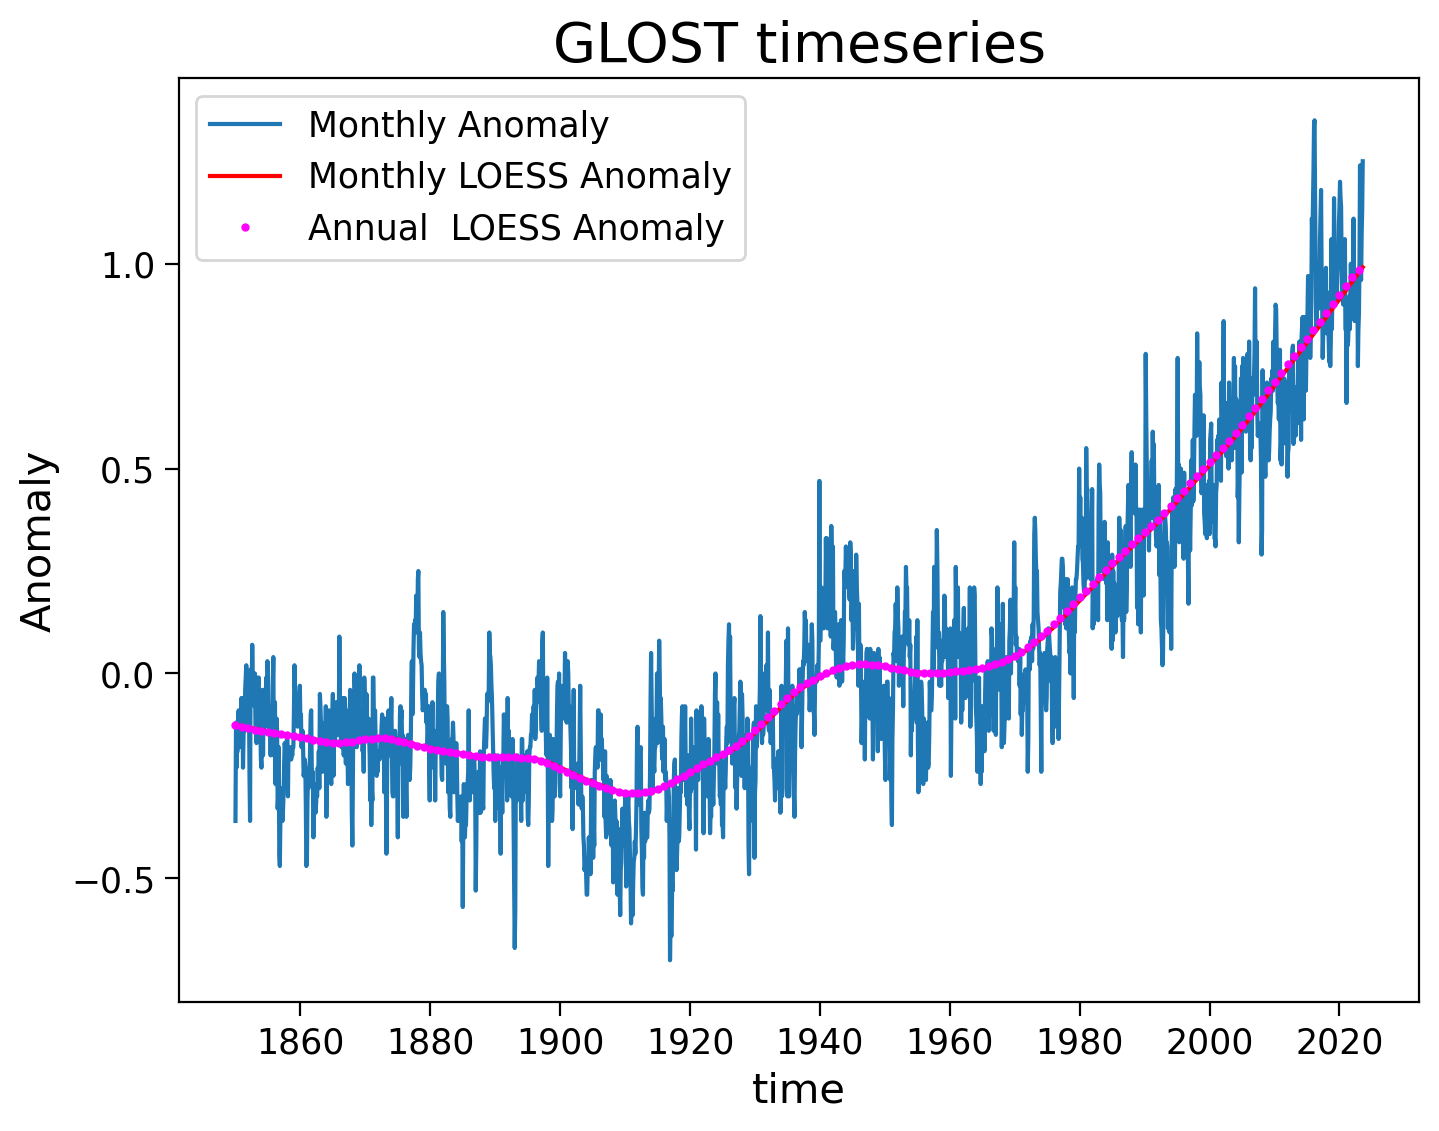

In [13]:
ds_glost['Anomaly'].plot(label='Monthly Anomaly')
plt.plot(ds_glost['time'], smooth_glost, color='red',label='Monthly LOESS Anomaly')
plt.plot(xxx, ann_glost,marker='o', linestyle='', color='magenta',markersize=2,label='Annual  LOESS Anomaly')
plt.legend()
plt.title('GLOST timeseries',fontsize=20)


In [14]:
ann_glost=ann_glost.sel(time=ds['time'])
ann_glost=ann_glost.rename({'Anomaly'})

# Merge AFI with GLOST

In [15]:
ds=ds.merge({'glost':ann_glost})

# Reduce domain for testing purpose

In [16]:
lon_min=235;lon_max=293
lat_min=28;lat_max=50

In [17]:
ds=ds.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon=ds.lon.data
Tlat=ds.lat.data

# Define EVGAM parameters for smoothness 

In [18]:
# parameters for smoothness 
%R fmla_gev <- list(AFI ~ s(glost,k=5) , ~ s(glost,k=5) , ~ 1)

o{'None': AFI ~ s(glost, k = 5)
, 'None': ~s(glost, k = 5)
, 'None': ~1
, }

# evgam fit_gev and rl100

In [19]:
Rlocation=xr.zeros_like(ds['AFI'].load())*np.nan
Rshape=xr.zeros_like(ds['AFI'].load())*np.nan
Rscale=xr.zeros_like(ds['AFI'].load())*np.nan
Rrl100=xr.zeros_like(ds['AFI'].load())*np.nan

mask=xr.where(np.isnan(ds['AFI'].mean('time'))==False,1,0)

idlat,idlon=np.where(mask==1)
for ij in range(0,len(idlat)):
  jj=idlat[ij]
  ii=idlon[ij]
  ilon=Tlon[ii]
  ilat=Tlat[jj]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  if df.empty == True:
    Rlocation.loc[{'lat':ilat,'lon':ilon}]=-999
    Rscale.loc[{'lat':ilat,'lon':ilon}]=-999
    Rshape.loc[{'lat':ilat,'lon':ilon}]=-999
    Rrl100.loc[{'lat':ilat,'lon':ilon}]=-999
  else:  
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    r_df = ro.conversion.py2rpy(df)
    globalenv['r_df'] = r_df

    # EVGAM model fitting  
    %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
    %R gev_pred <- predict(m_gev, r_df, type = "response")
    %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
    %R -o gev_pred,gev_rl100 # get R data to python

    # Convert R data.frame to xarray
    gev_pred['time']=df['time'].values
    dsgev_pred=gev_pred.set_index(['time']).to_xarray()

    ######
    ######
    gev_rl100['time']=df['time'].values
    dsgev_rl100=gev_rl100.set_index(['time']).to_xarray()
    
    ######
    ######

    Rlocation.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['location'][:]
    Rscale.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['scale'][:]
    Rshape.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_pred['shape'][:]
    Rrl100.loc[{'time':df['time'].values,'lat':ilat,'lon':ilon}]=dsgev_rl100['q:0.99'][:]


R[write to console]: Final Hessian of negative penalized log-likelihood not numerically positive definite.



boxes in grey

# Read GEV parameters with scipy.stats.

In [20]:

file0=f'../AFI/afi_return.fullUSA.gev.1980_2008_KS.nc'
ds0=xr.open_dataset(file0)
ds0=ds0.sortby('lat')
ds0=ds0.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

Slocation = ds0['location']*5/9.
Sshape = ds0['shape']
Sscale = ds0['scale']*5/9.
Srl100 = ds0['return_afi'].sel(return_periods=100)*5/9.

The 100-year return level is expressed in degree-days (C).

In [21]:
from copy import copy
cmap200=copy(cmaps.BlGrYeOrReVi200)
cmap200.set_under('darkgrey', 1.0)
#
cmapBR=copy(cmaps.ncl_default)
cmapBR.set_under('darkgrey', 1.0)
#
cmapBR_r=copy(cmaps.ncl_default_r)
cmapBR_r.set_under('darkgrey', 1.0)
#
proj=ccrs.PlateCarree()

# Plot location

<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:35: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/582749475.py:35: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/582749475.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


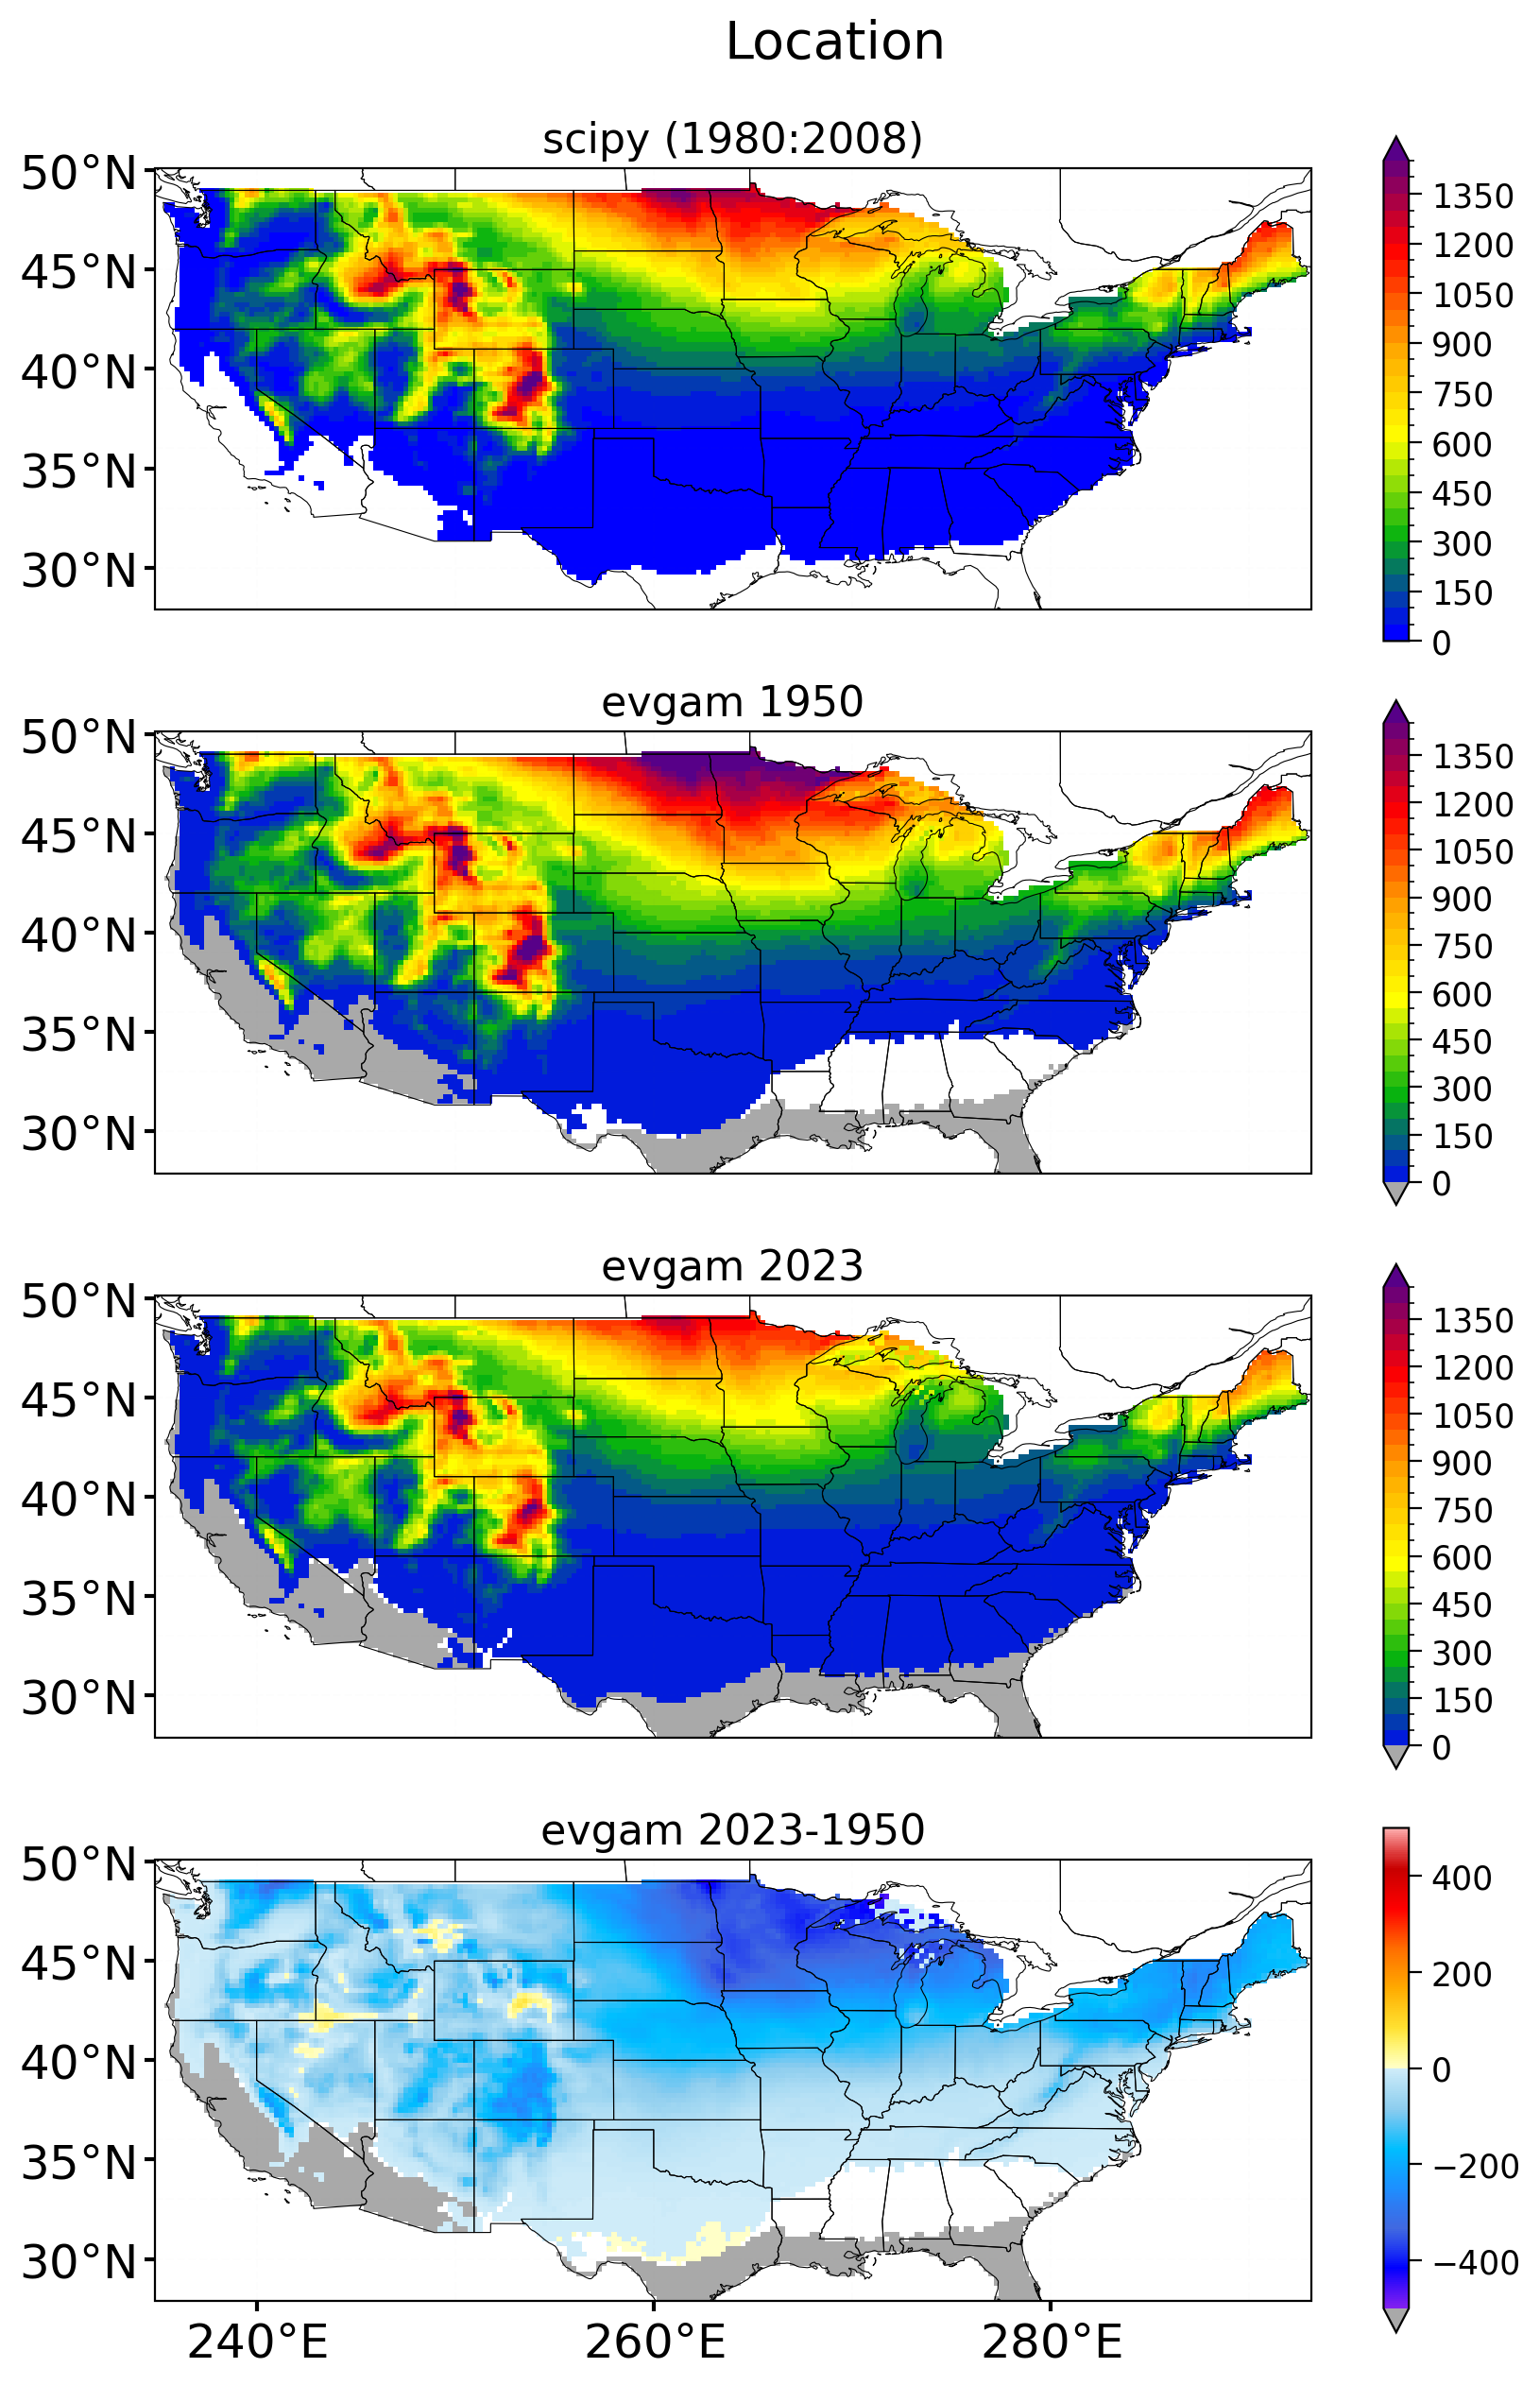

In [22]:

fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Location
#
clevs = np.arange(0,1500,50)

Slocation.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rlocation.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rlocation.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rlocation.isel(time=73)-Rlocation.isel(time=0)
data=xr.where(Rlocation.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-500,vmax=500,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')

  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Location',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_location.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')


In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Scale

<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/4129707890.py:34: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/4129707890.py:37: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


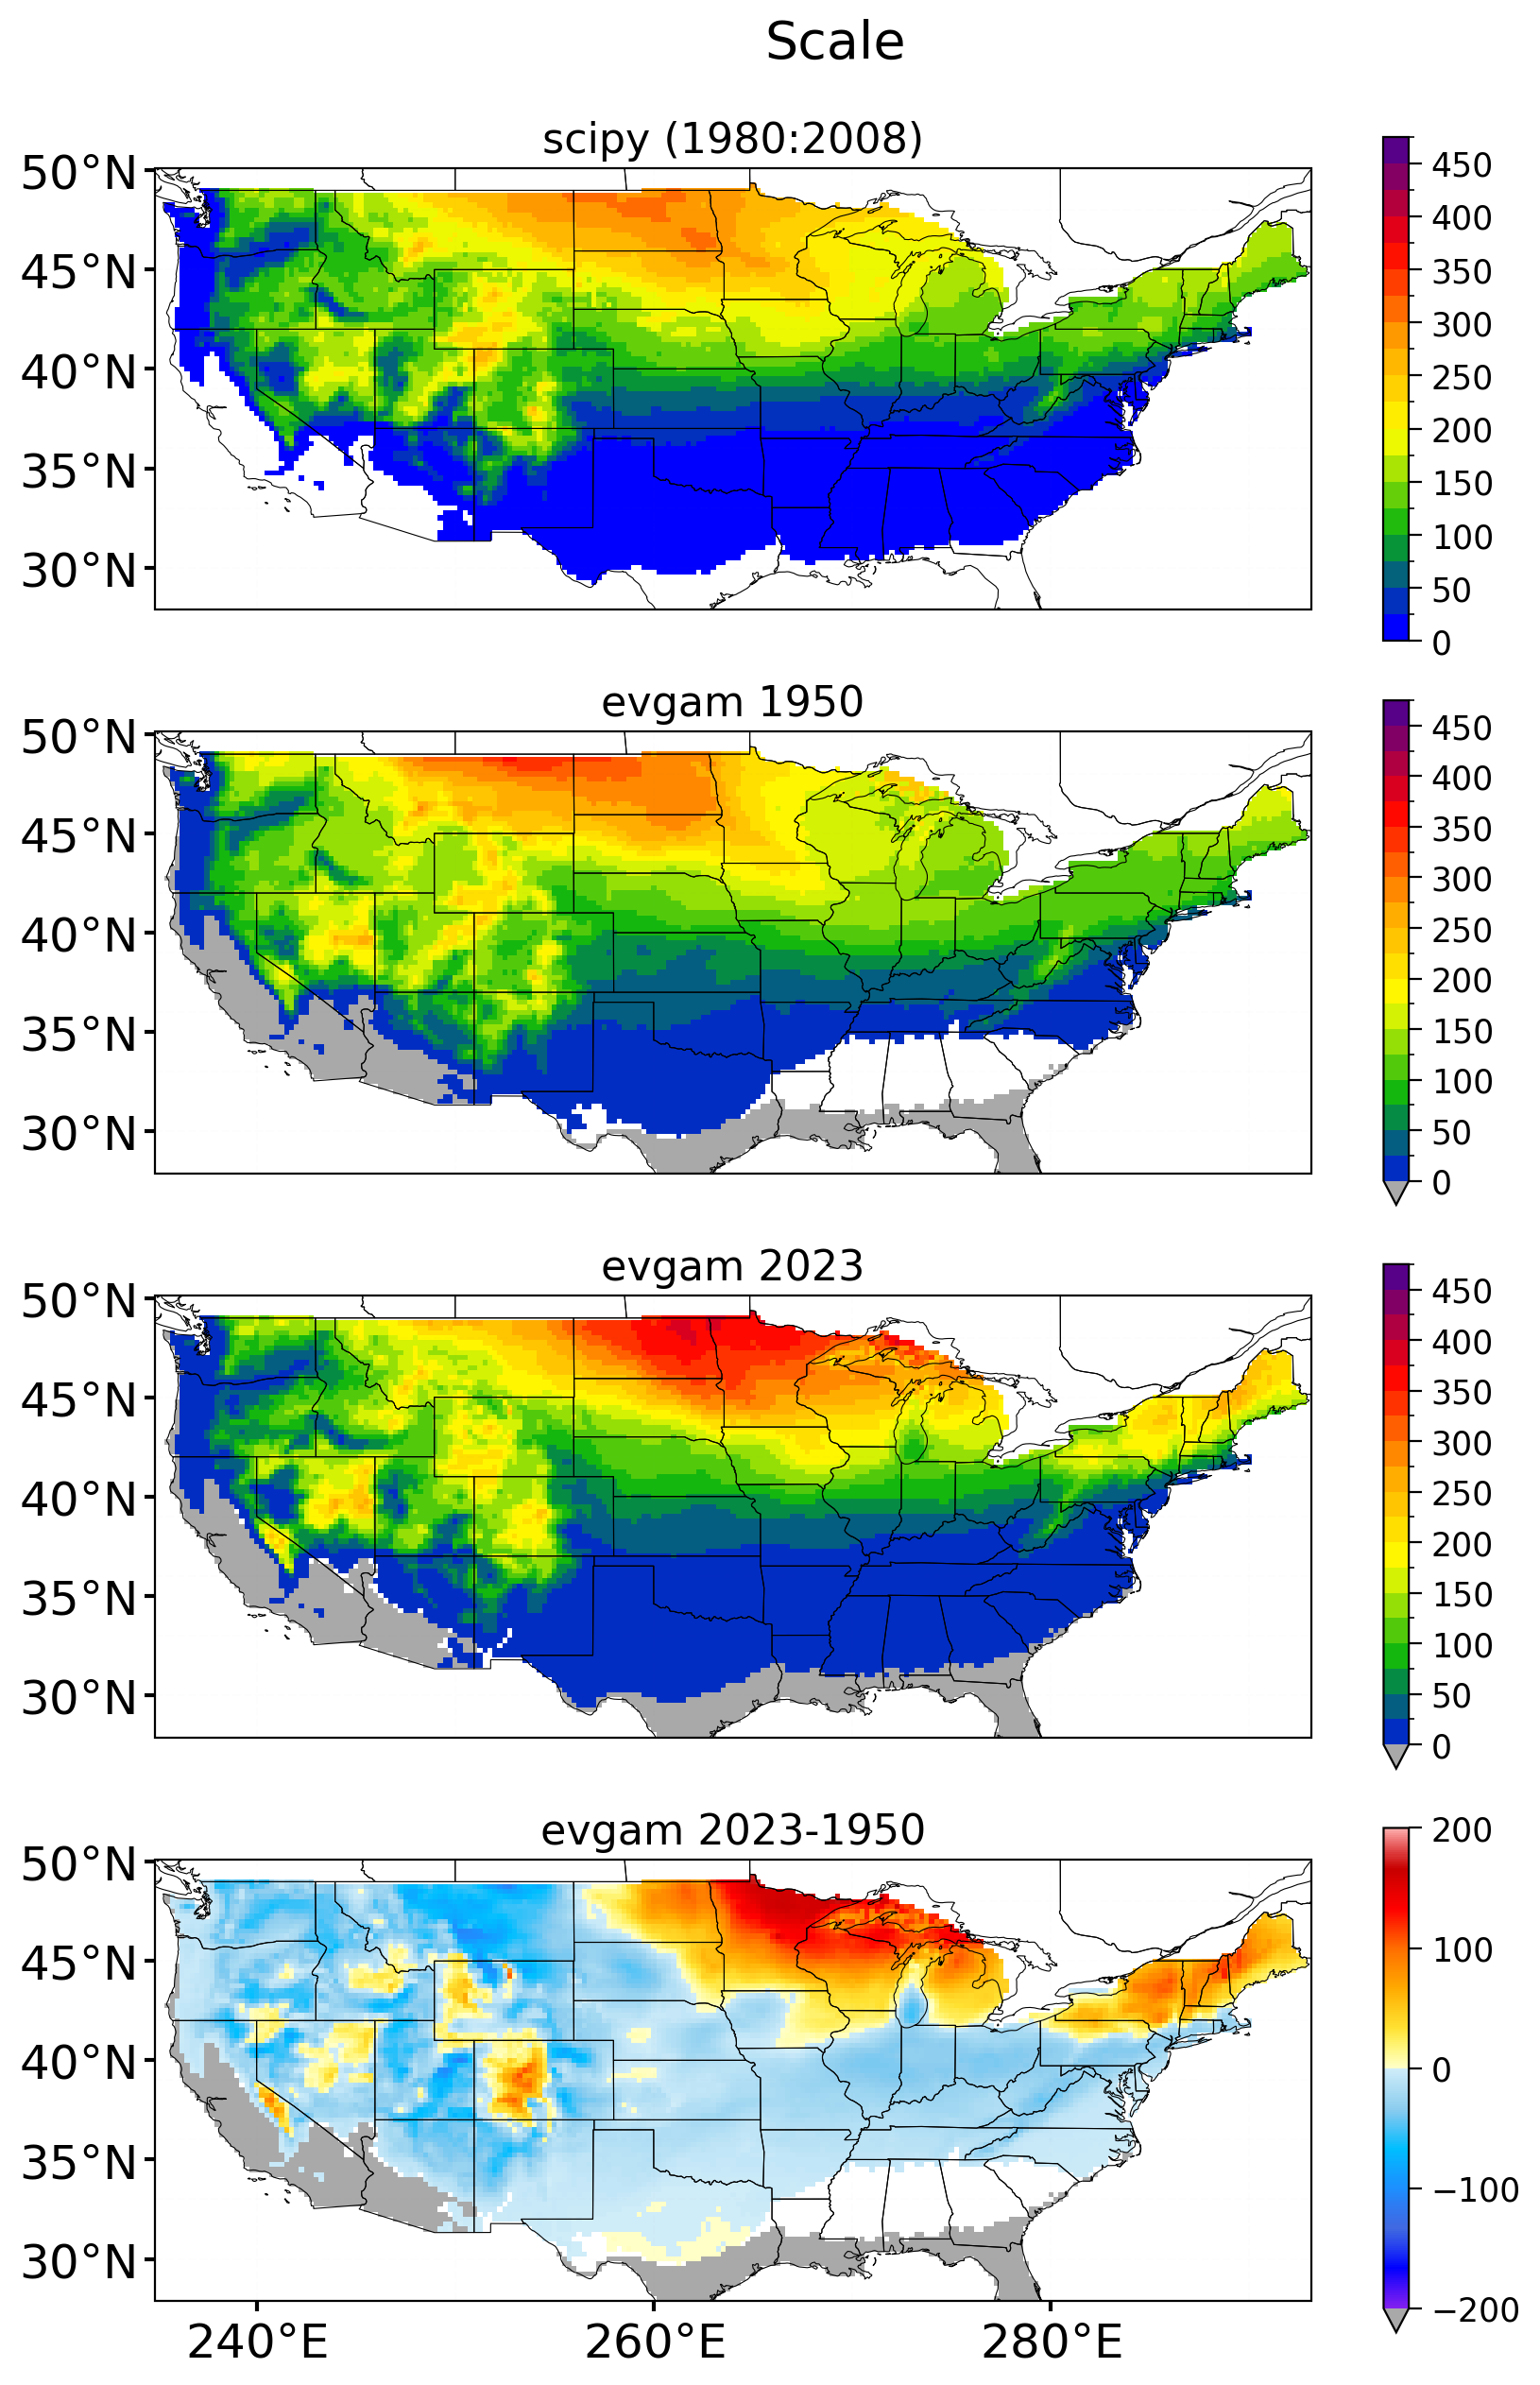

In [23]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,500,25)

Sscale.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rscale.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rscale.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rscale.isel(time=73)-Rscale.isel(time=0)
data=xr.where(Rscale.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-200,vmax=200,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Scale',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_scale.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.

# Plot Shape

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/4193660454.py:37: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/4193660454.py:40: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


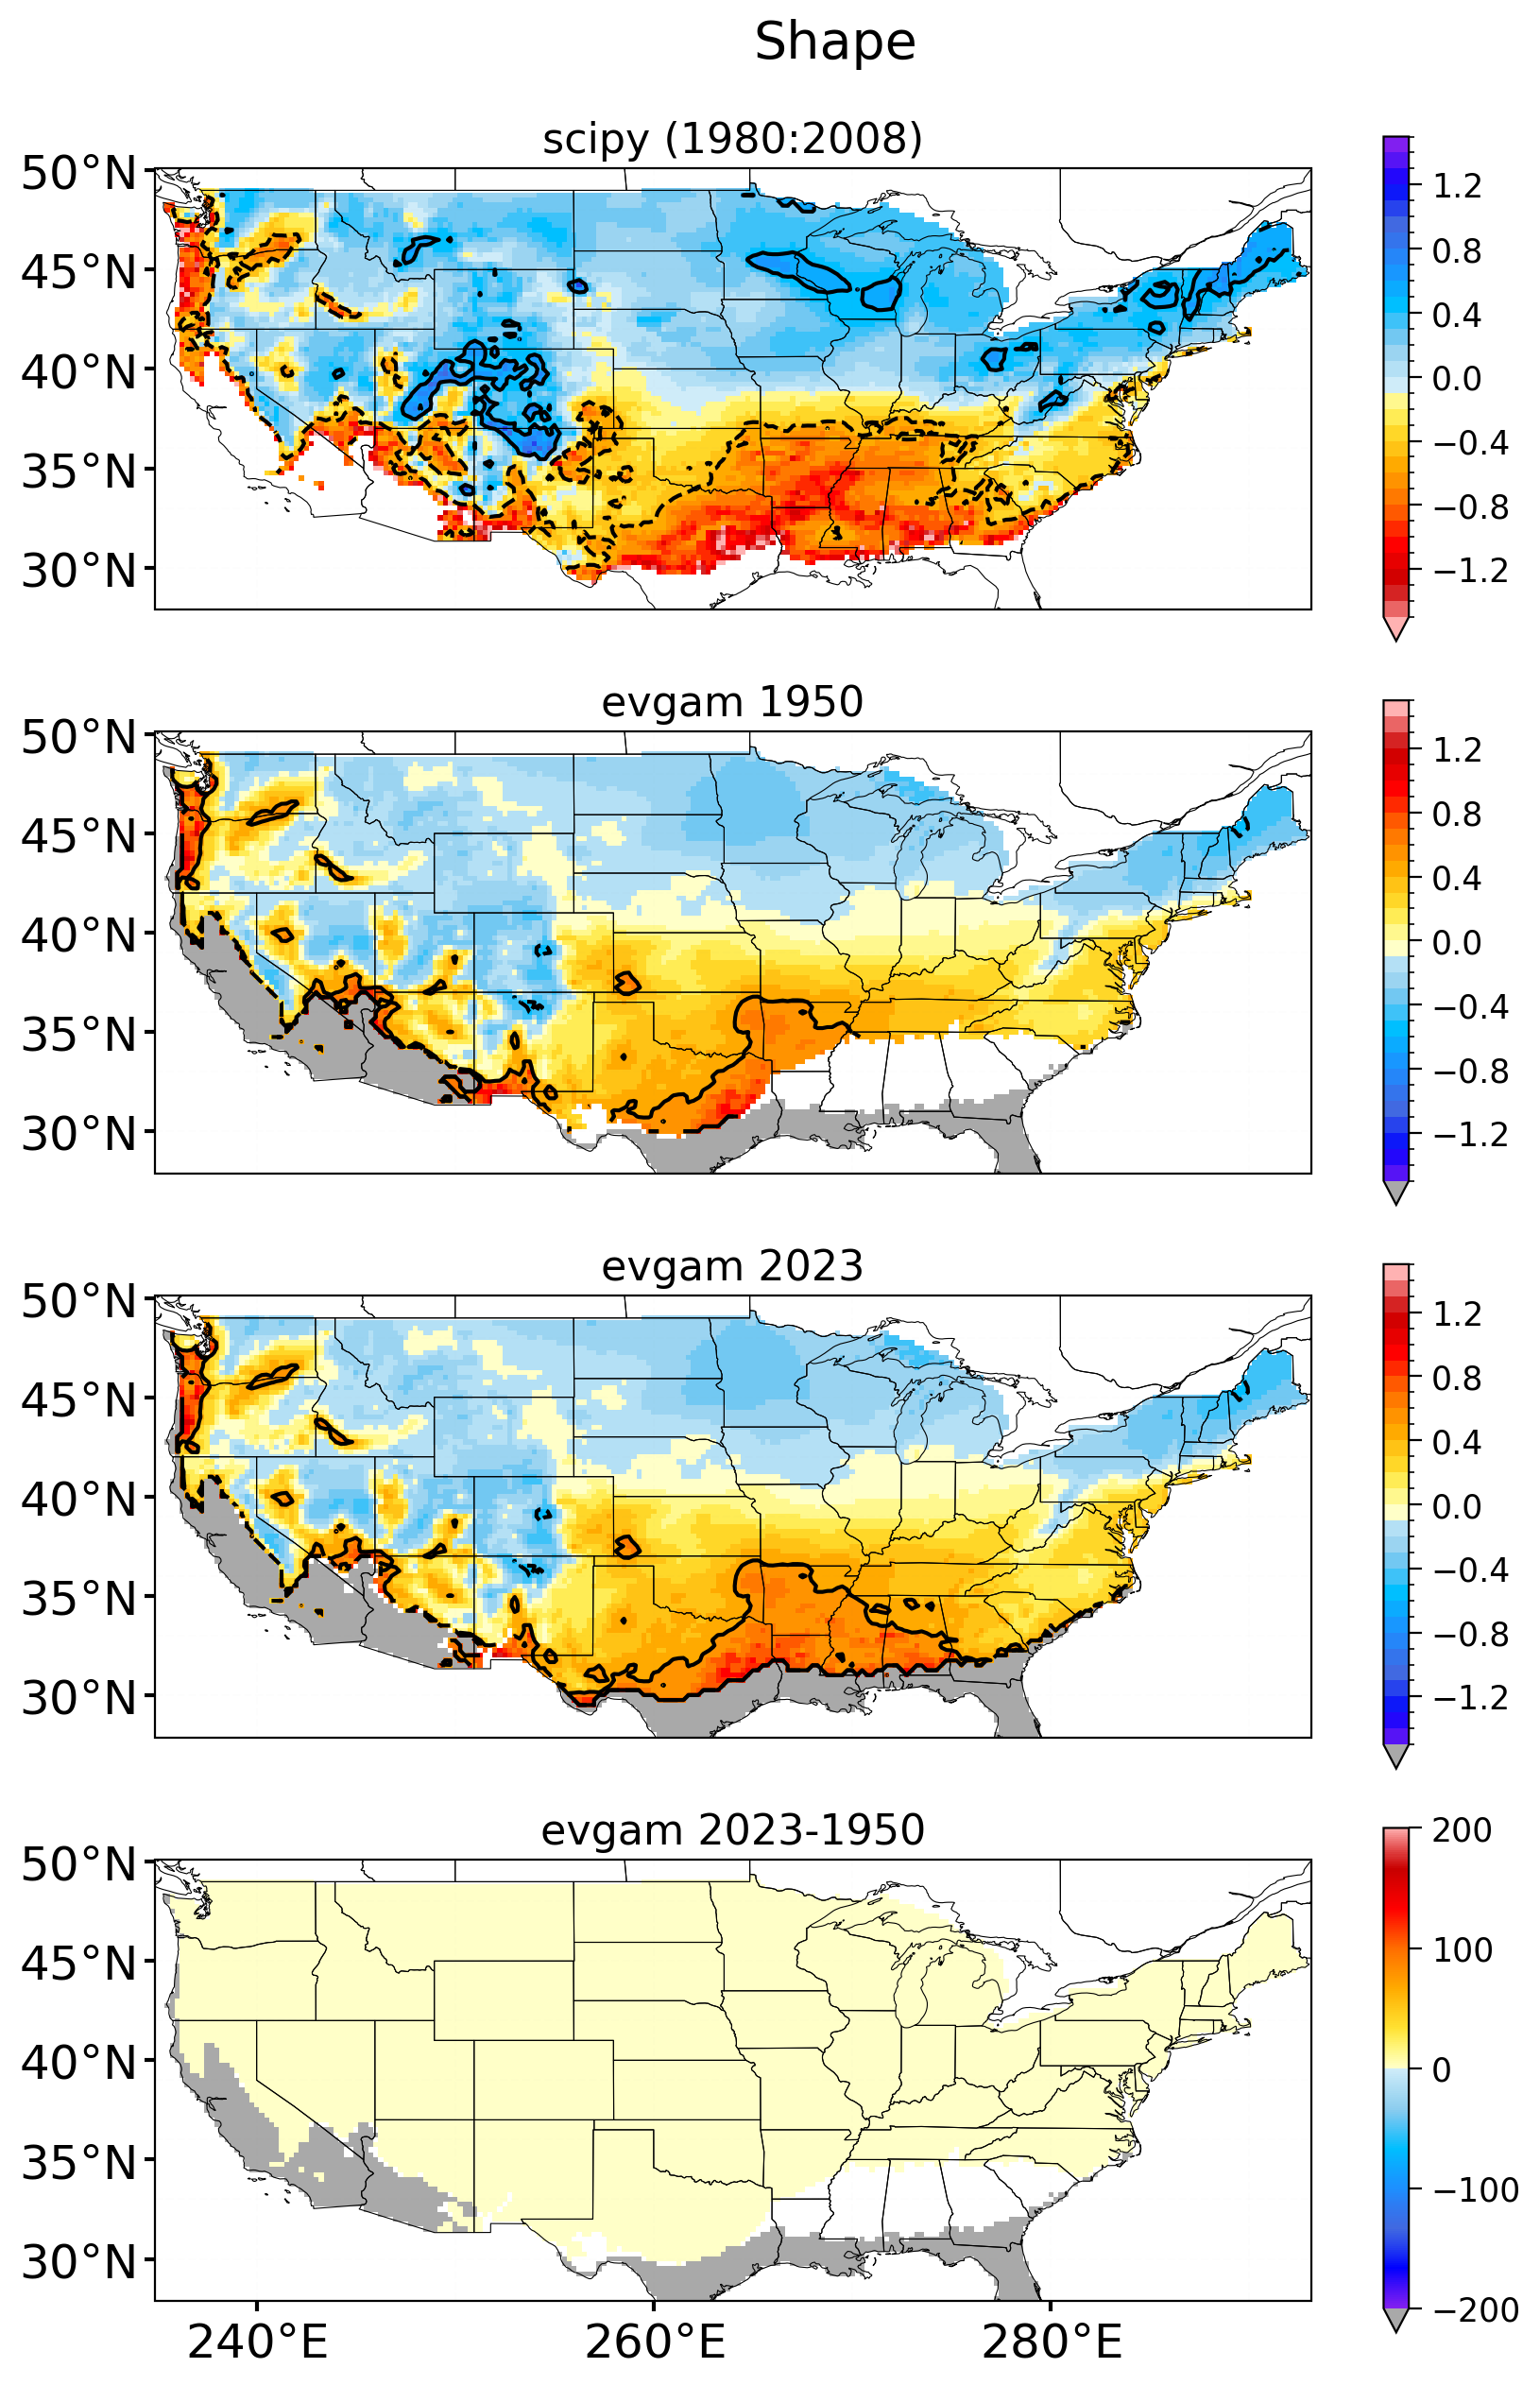

In [24]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(-1.5,1.6,0.1)

Sshape.plot(ax=ax[0],cmap=cmaps.ncl_default_r,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].contour(Sshape['lon'],Sshape['lat'],Sshape,levels=[-0.5,0.5],colors='k')
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rshape.isel(time=0).plot(ax=ax[1],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=0),levels=[-0.5,0.5],colors='k')
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rshape.isel(time=73).plot(ax=ax[2],cmap=cmapBR,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rshape.isel(time=73)-Rshape.isel(time=0)
data=xr.where(Rshape.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR,vmin=-200,vmax=200,cbar_kwargs={'label':'','shrink':shrink})
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('Shape',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_shape.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.
The black contours are showing the shape parameters outside of [-0.5,0.5].

# Plot 100y Return Level 

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/538901517.py:38: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/538901517.py:41: SyntaxWarning: invalid escape sequence '\d'
  ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)


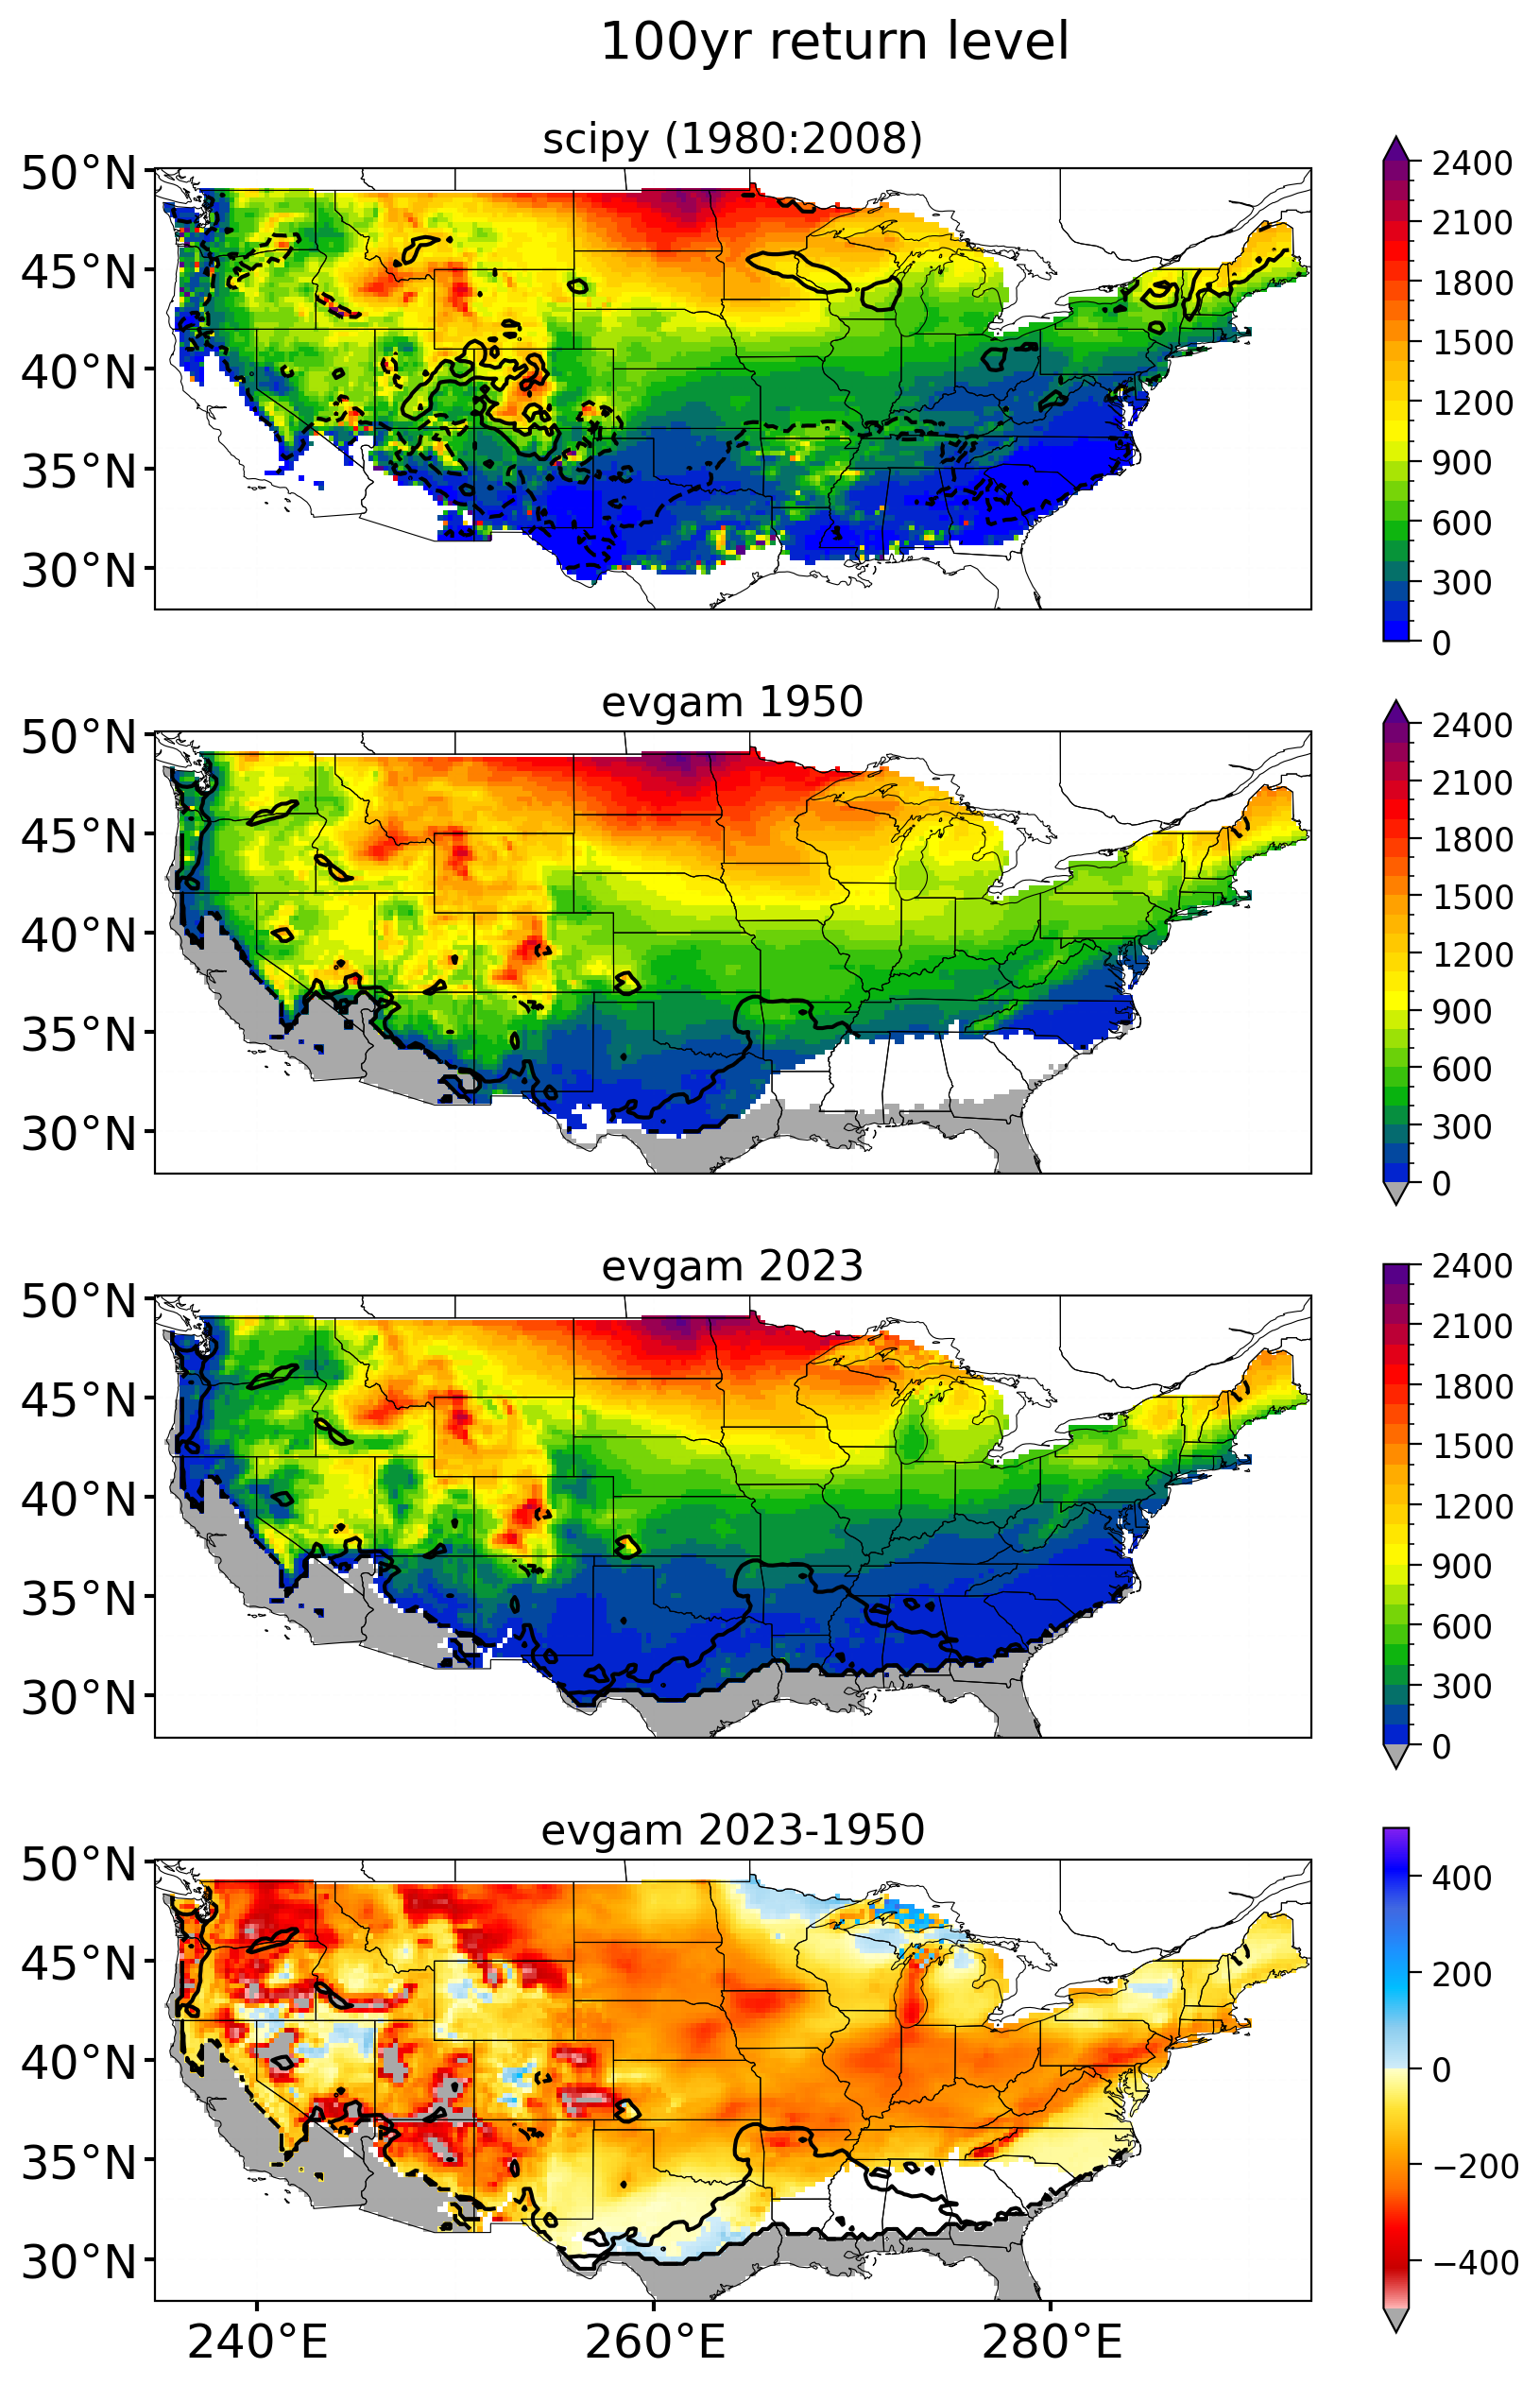

In [25]:
fig, ax = plt.subplots(nrows=4,ncols=1,figsize=(9,13),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)
ax=ax.flatten()

shrink=0.85
#
#  Scale
#
clevs = np.arange(0,2500,100)

Srl100.plot(ax=ax[0],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[0].contour(Sshape['lon'],Sshape['lat'],Sshape,levels=[-0.5,0.5],colors='k')
ax[0].set_title('scipy (1980:2008)',fontsize=16)

Rrl100.isel(time=0).plot(ax=ax[1],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[1].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=0),levels=[-0.5,0.5],colors='k')
ax[1].set_title(f'evgam {yearb}',fontsize=16)

Rrl100.isel(time=73).plot(ax=ax[2],cmap=cmap200,levels=clevs,cbar_kwargs={'label':'','shrink':shrink})
ax[2].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[2].set_title(f'evgam {yeare}',fontsize=16)

data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data=xr.where(Rrl100.isel(time=0)==-999,-999,data)
data.plot(ax=ax[3],cmap=cmapBR_r,vmin=-500,vmax=500,cbar_kwargs={'label':'','shrink':shrink})
ax[3].contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')
ax[3].set_title(f'evgam {yeare}-{yearb}',fontsize=16)
####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=18)
  if ix == 3: 
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax[ix].get_xticks()],size=18)
  else:
    ax[ix].set_xticklabels('')  
fig.suptitle('100yr return level',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_rl100.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

In grey, not enough AFI > 0. for that point (value chosen as threshold : 49). 
In white, evgam output undefined.
The black contours are showing the shape parameters outside of [-0.5,0.5].

# Write outfile 

In [26]:
dsout=Rrl100.to_dataset(name='rl100')
dsout=dsout.merge({'location':Rlocation,'scale':Rscale,'shape':Rshape})
dsout.to_netcdf(f'../AFI/afi_return.evgam.{yearb}_{yeare}_{itest}.nc')

# Bilotta - Like figure 4

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/590992898.py:25: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/590992898.py:28: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


min: -851.3887083429915 max: 185.76896432345848


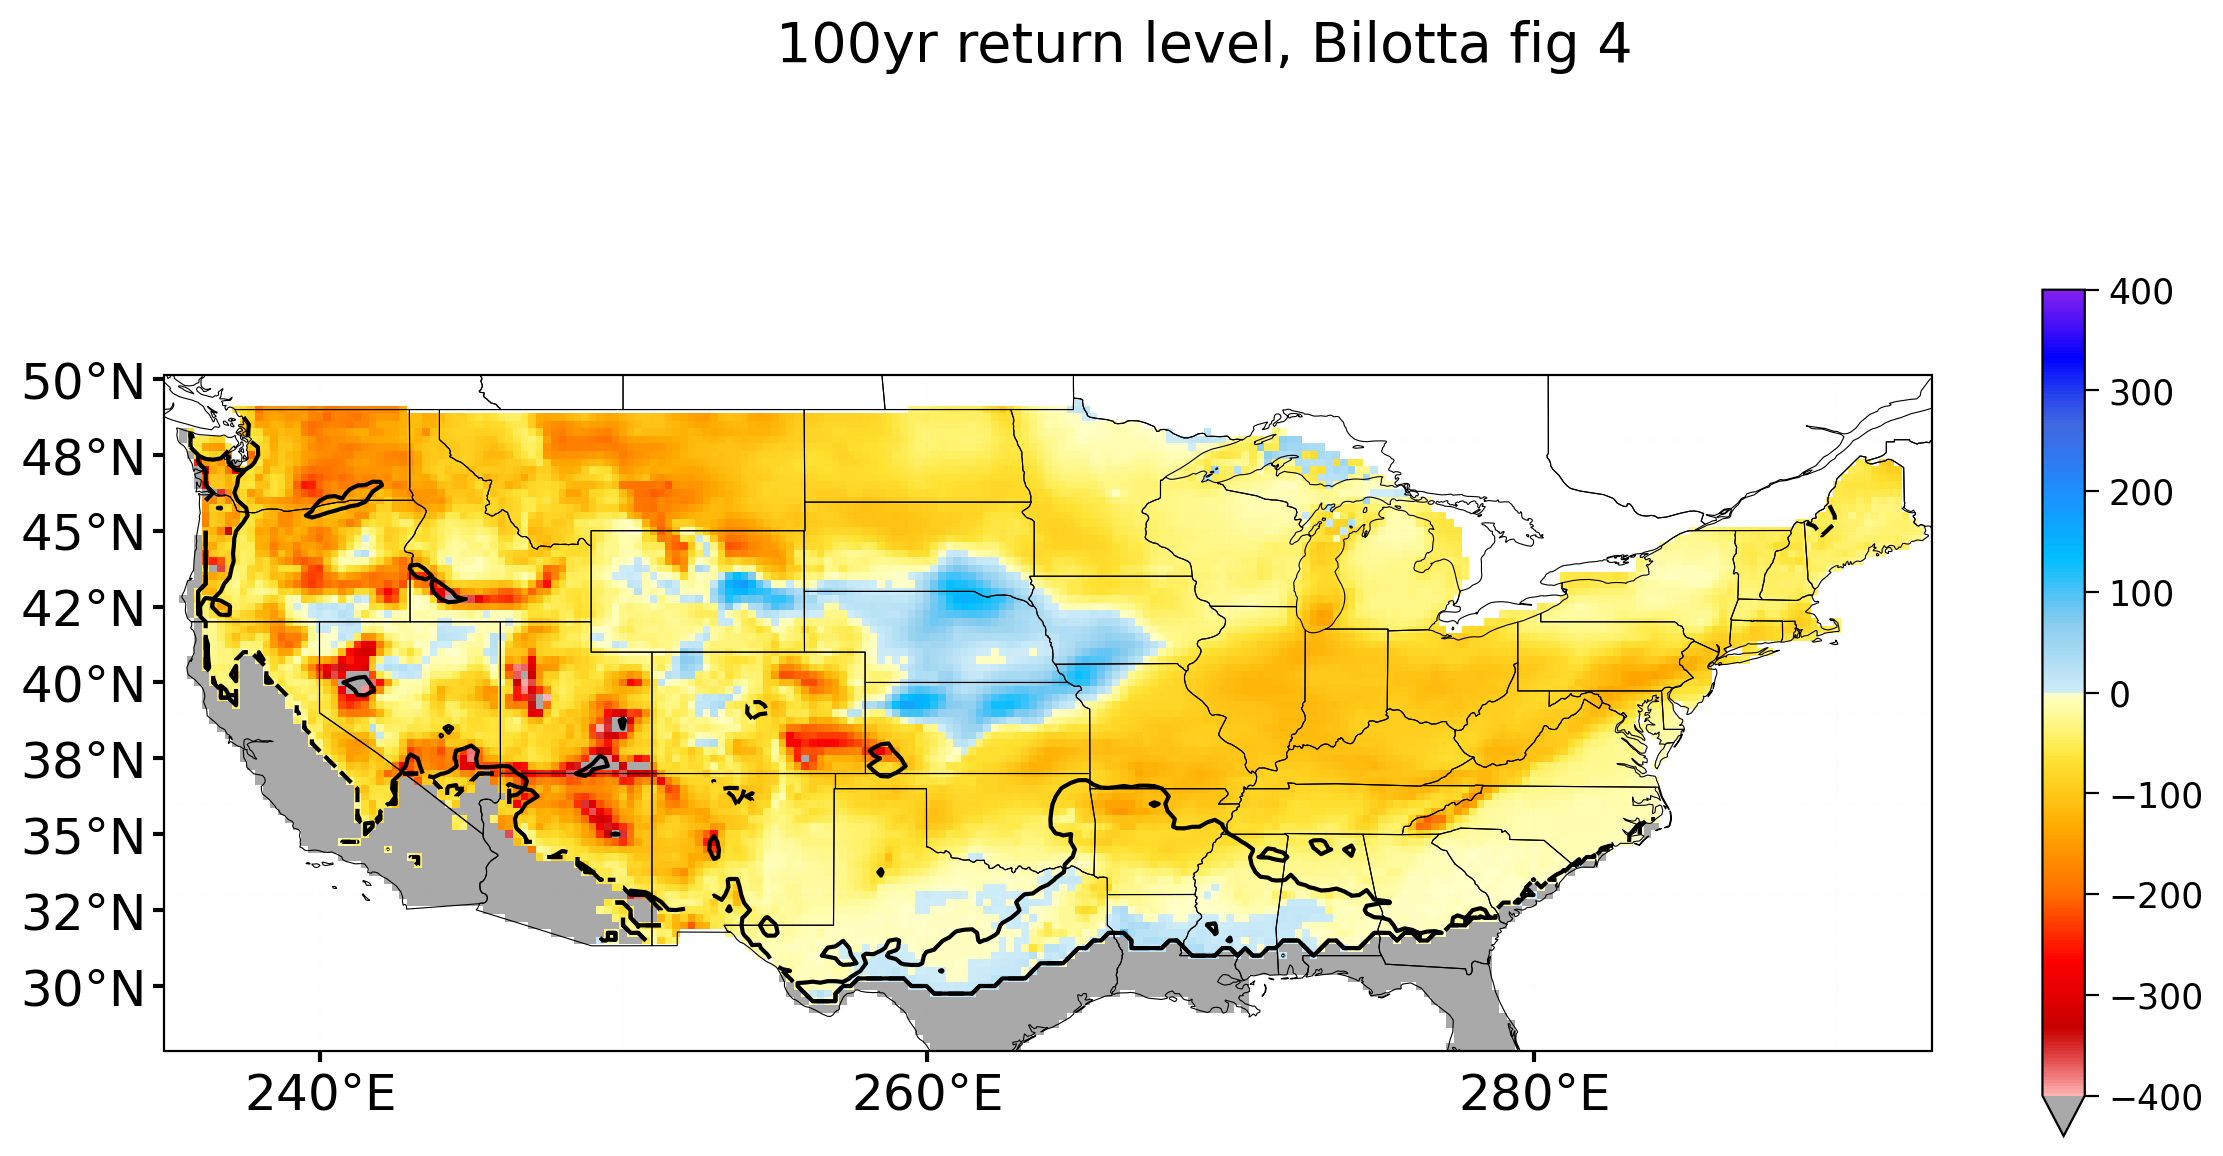

In [27]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(13,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.02,top=0.95, left=0.1,right=0.95,hspace=-0.05)

shrink=0.65
#
#  Scale
#

data1081 = Rrl100.sel(time=slice(1981,2010)).mean('time')
data8051 = Rrl100.sel(time=slice(1951,1980)).mean('time')
data = data1081 - data8051
print('min:',data.min().data,'max:',data.max().data)
data=xr.where(Rrl100.isel(time=0)==-999,-99999,data)
data.plot(ax=ax,cmap=cmapBR_r,vmin=-400,vmax=400,cbar_kwargs={'label':'','shrink':shrink})
ax.contour(Rshape['lon'],Rshape['lat'],Rshape.isel(time=73),levels=[-0.5,0.5],colors='k')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title('')
fig.suptitle('100yr return level, Bilotta fig 4',fontsize=20)    
outfile=f'PLOTS/GEV_NS{itest}_figure4.png'
plt.savefig(outfile, dpi=150, facecolor='w', edgecolor='w', orientation='portrait')

The black contours are showing the shape parameters outside of [-0.5,0.5].

# GRID POINTS ANALYSIS

In [28]:
ptlon=[260,264.25,241,   242,253]
ptlat=[ 48, 37.  , 46.25, 40, 38]

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/1766693568.py:19: SyntaxWarning: invalid escape sequence '\d'
  ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)
/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/1766693568.py:22: SyntaxWarning: invalid escape sequence '\d'
  ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)


Text(0.5, 1.0, '100yr return level, 2023-1950')

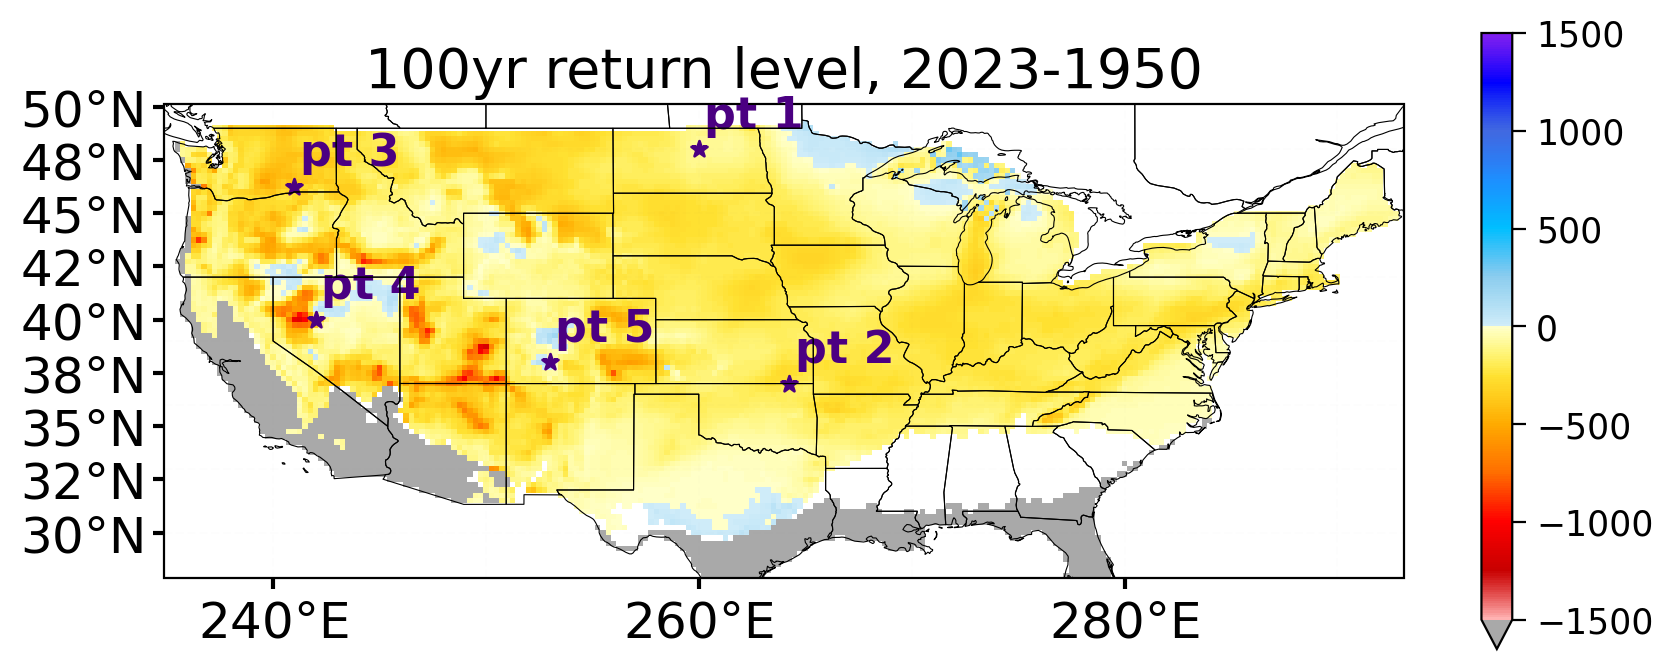

In [38]:
cmap=cmaps.BlGrYeOrReVi200

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,8),subplot_kw={'projection':proj})
data=Rrl100.isel(time=73)-Rrl100.isel(time=0)
data=xr.where(Rrl100.isel(time=0)==-999,-99999,data)
data.plot(cmap=cmapBR_r,vmin=-1500,vmax=1500,cbar_kwargs={'label':'','shrink':0.5})
for ip in range(0,len(ptlon)):
  ax.scatter(ptlon[ip],ptlat[ip],marker='*',color='indigo')
  ax.text(ptlon[ip]-360+0.25,ptlat[ip]+1,f'pt {ip+1}',color='indigo',size=16,weight='bold')

grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both',direction='out',width=1.5,length=4)
ax.set_yticks(ax.get_yticks()[1:-1],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=18)

ax.set_xticks(ax.get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx+360)}$\degree$E' for ixx in ax.get_xticks()],size=18)
ax.set_title(f'100yr return level, {yeare}-{yearb}',fontsize=20)

<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:91: SyntaxWarning: invalid escape sequence '\d'
<>:95: SyntaxWarning: invalid escape sequence '\d'
<>:95: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:45: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid e

#############
#############
Point 1
#############
#############


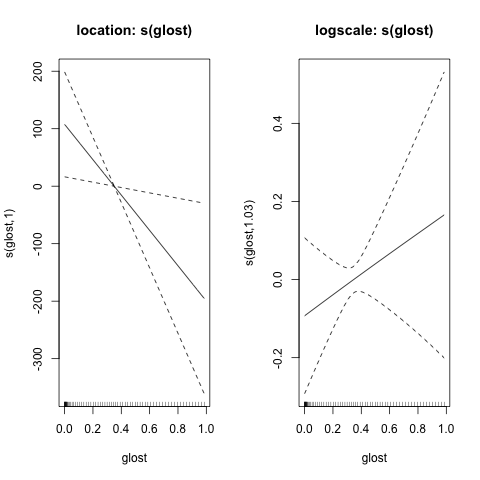


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1239.57      42.16    29.4   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     5.74        0.1   57.54   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.26        0.1    -2.5  0.00623

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   5.56   0.0184

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      4   0.85    0.361
#############
#############
Point 2
#############
#############


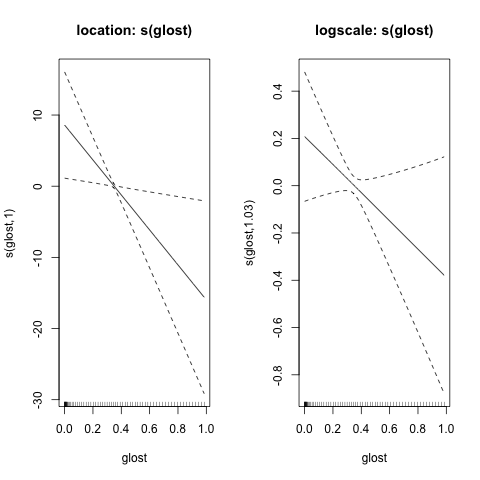


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    42.83          4    10.7   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     3.34       0.12   27.14   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.39       0.13    2.98  0.00143

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   5.32   0.0213

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      4   2.33    0.131
#############
#############
Point 3
#############
#############


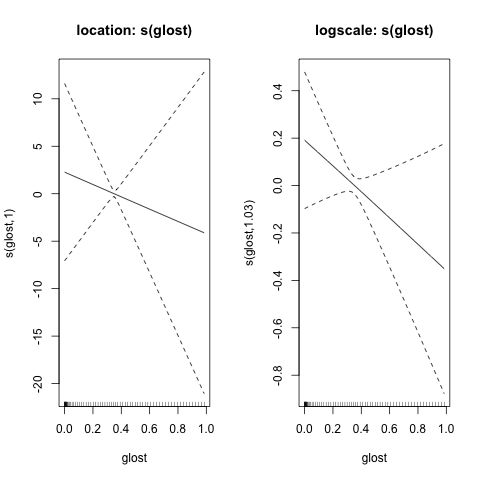


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    38.25        5.3    7.22 2.62e-13

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     3.58       0.14   25.95   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.52       0.15    3.36 0.000396

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   0.24    0.628

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      4    1.8    0.188
#############
#############
Point 4
#############
#############


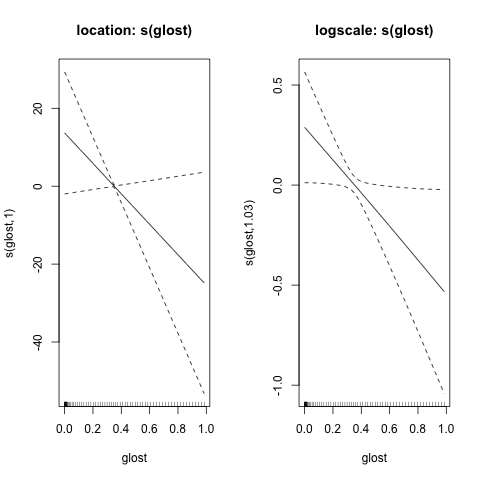


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    73.18       9.66    7.57 1.81e-14

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     4.12       0.13   31.91   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     0.35       0.16    2.21   0.0137

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4   3.05   0.0807

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.03      4   4.44   0.0375
#############
#############
Point 5
#############
#############


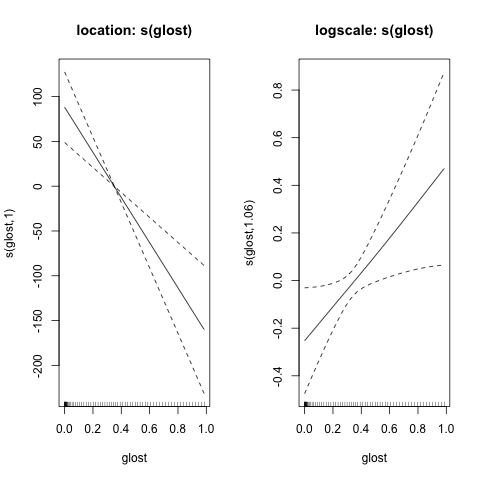


** Parametric terms **

location
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  1333.03      16.94   78.71   <2e-16

logscale
            Estimate Std. Error t value Pr(>|t|)
(Intercept)     4.84       0.09   53.35   <2e-16

shape
            Estimate Std. Error t value Pr(>|t|)
(Intercept)    -0.09       0.07   -1.16    0.123

** Smooth terms **

location
         edf max.df Chi.sq Pr(>|t|)
s(glost)   1      4  20.05 7.55e-06

logscale
          edf max.df Chi.sq Pr(>|t|)
s(glost) 1.06      4   5.65   0.0214


/var/folders/2z/v4x6xdj96rg1k3xrmwt26xtc0000gp/T/ipykernel_21781/880608117.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots()


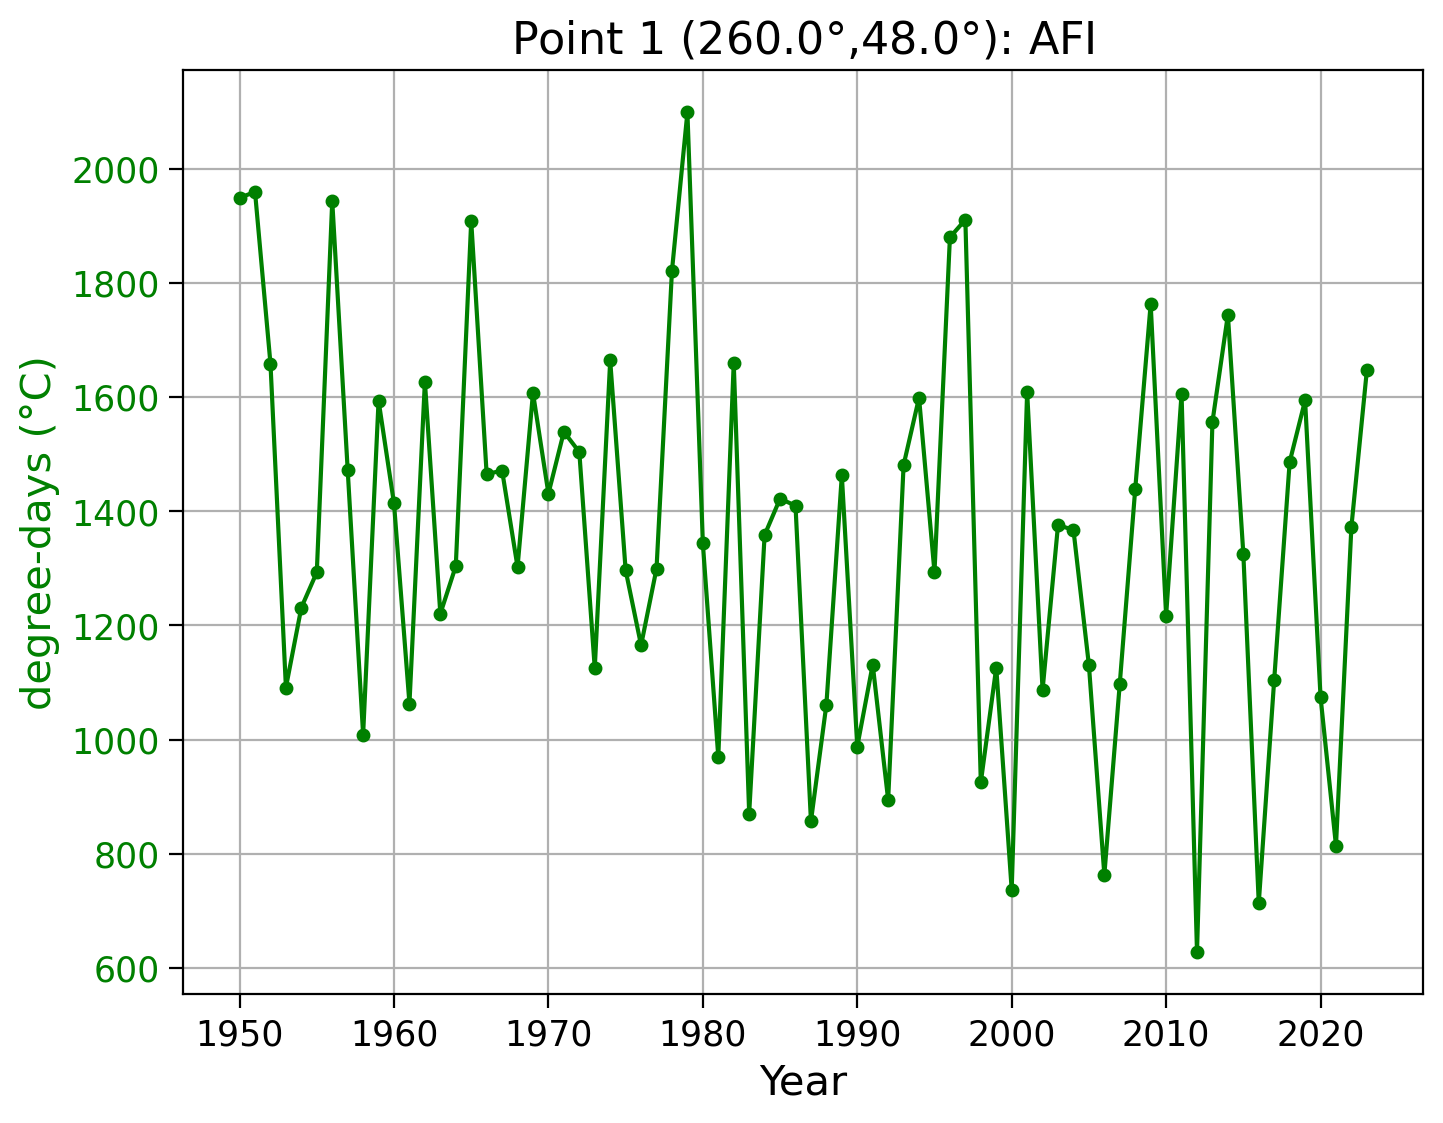

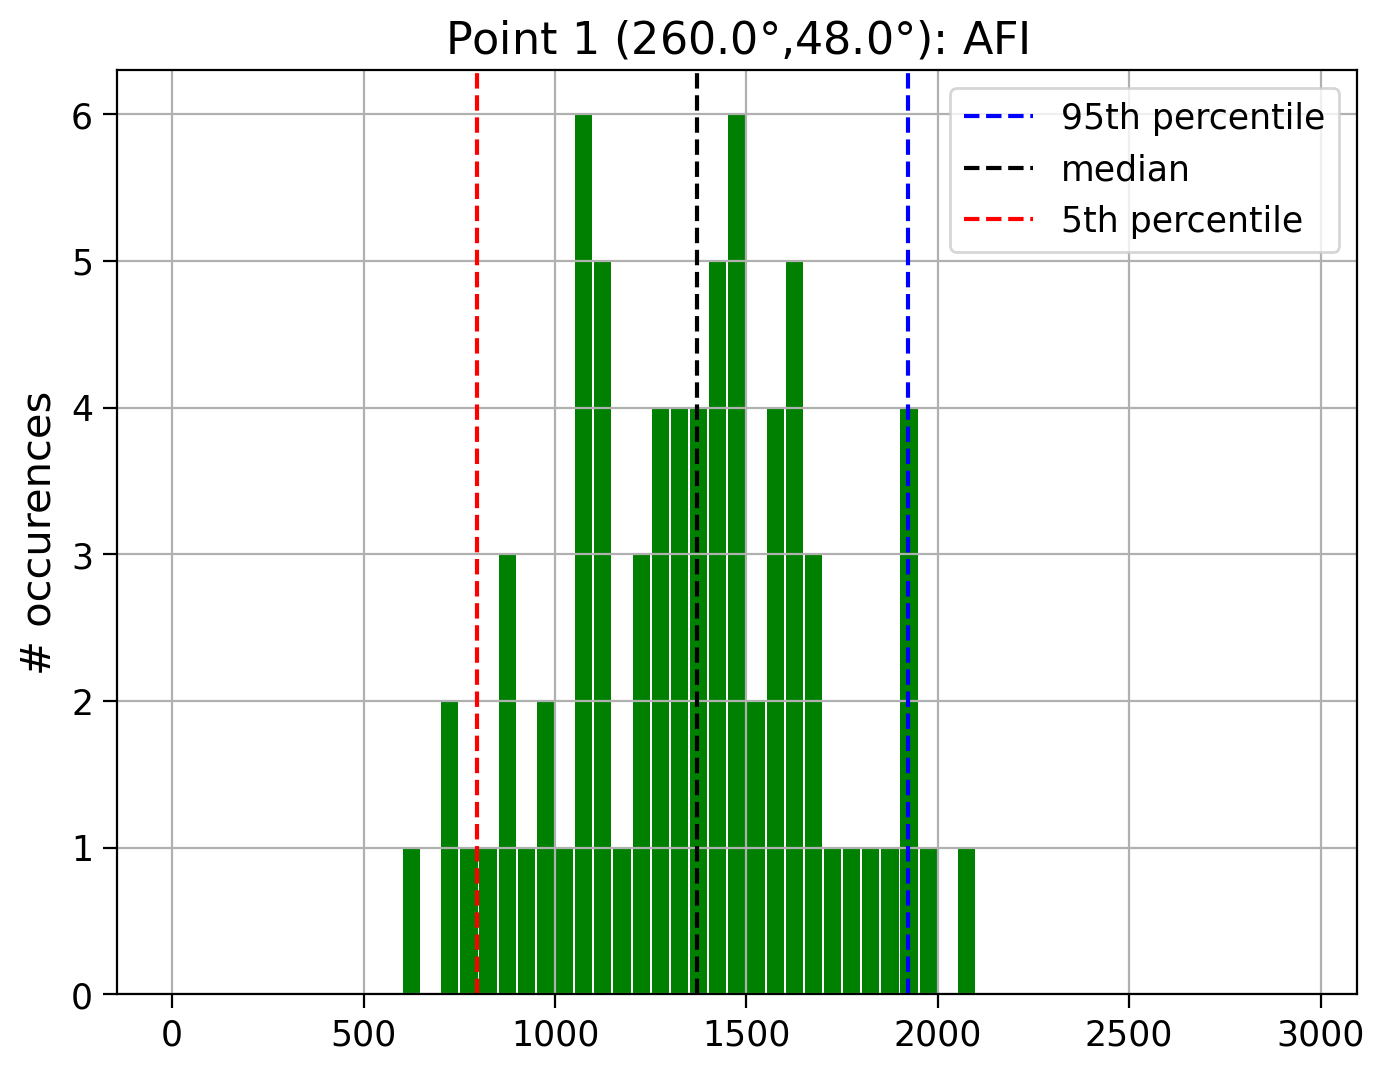

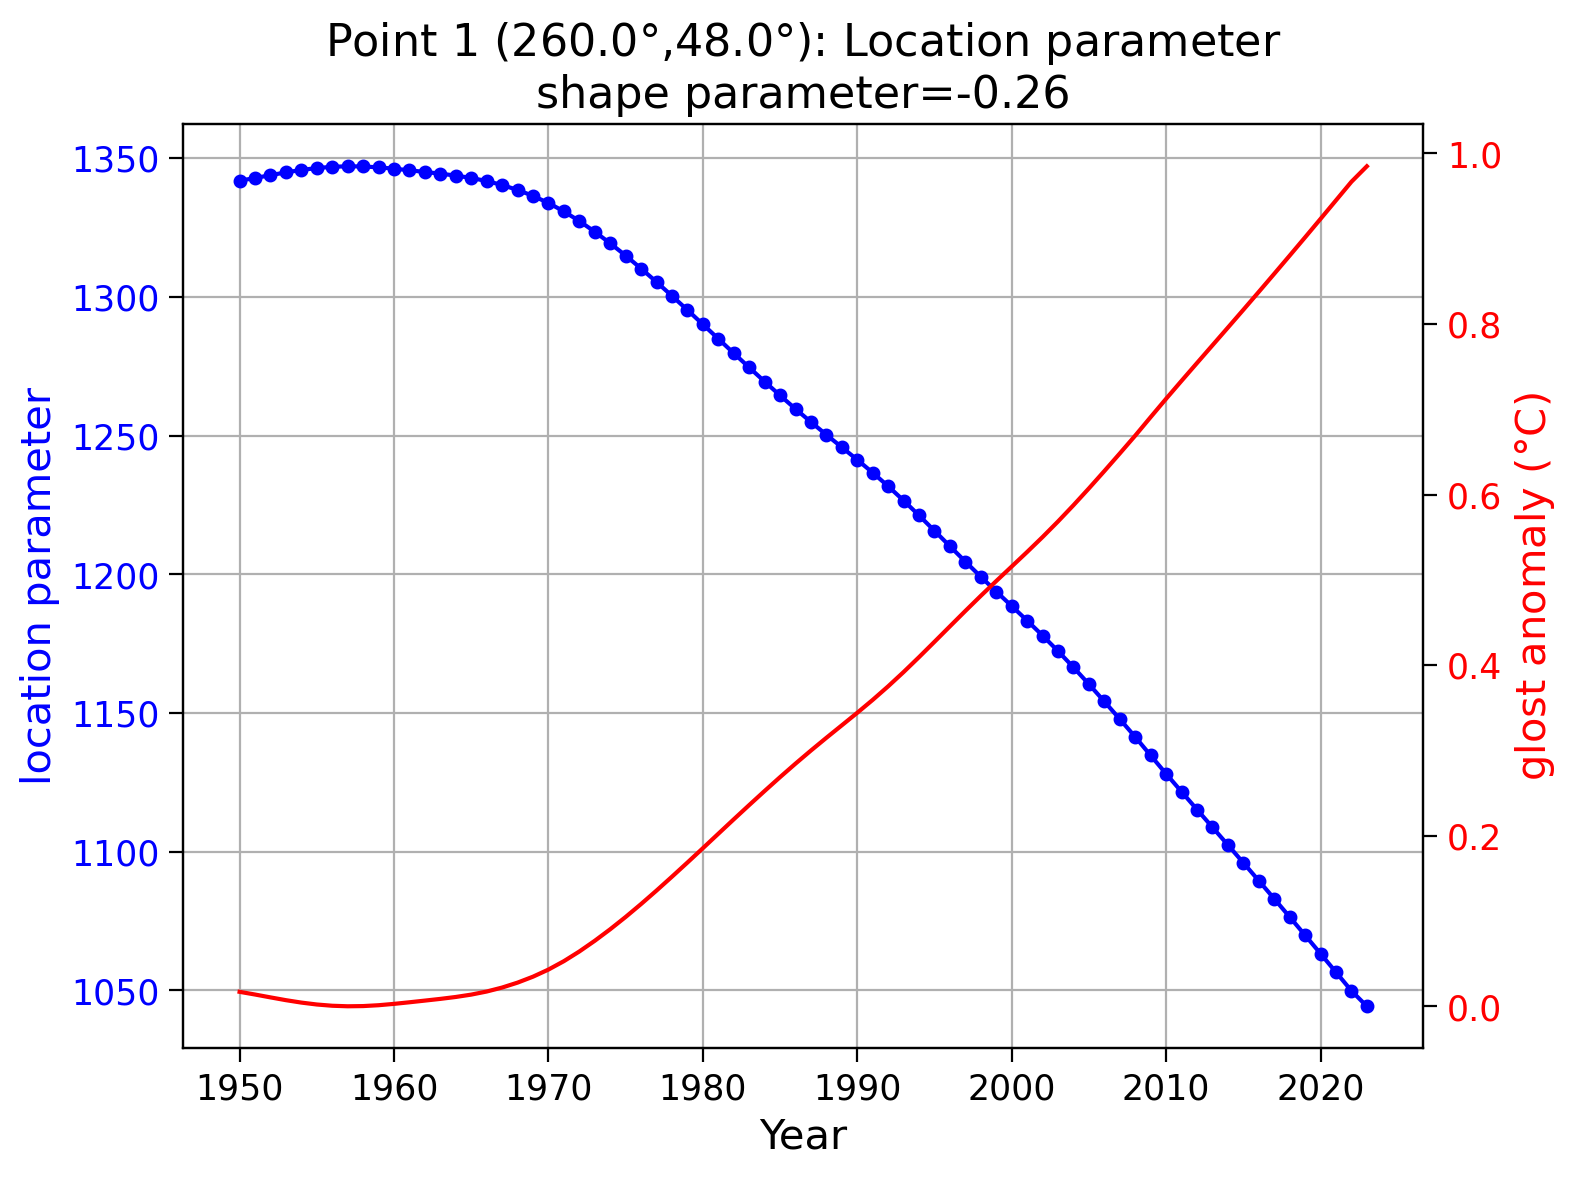

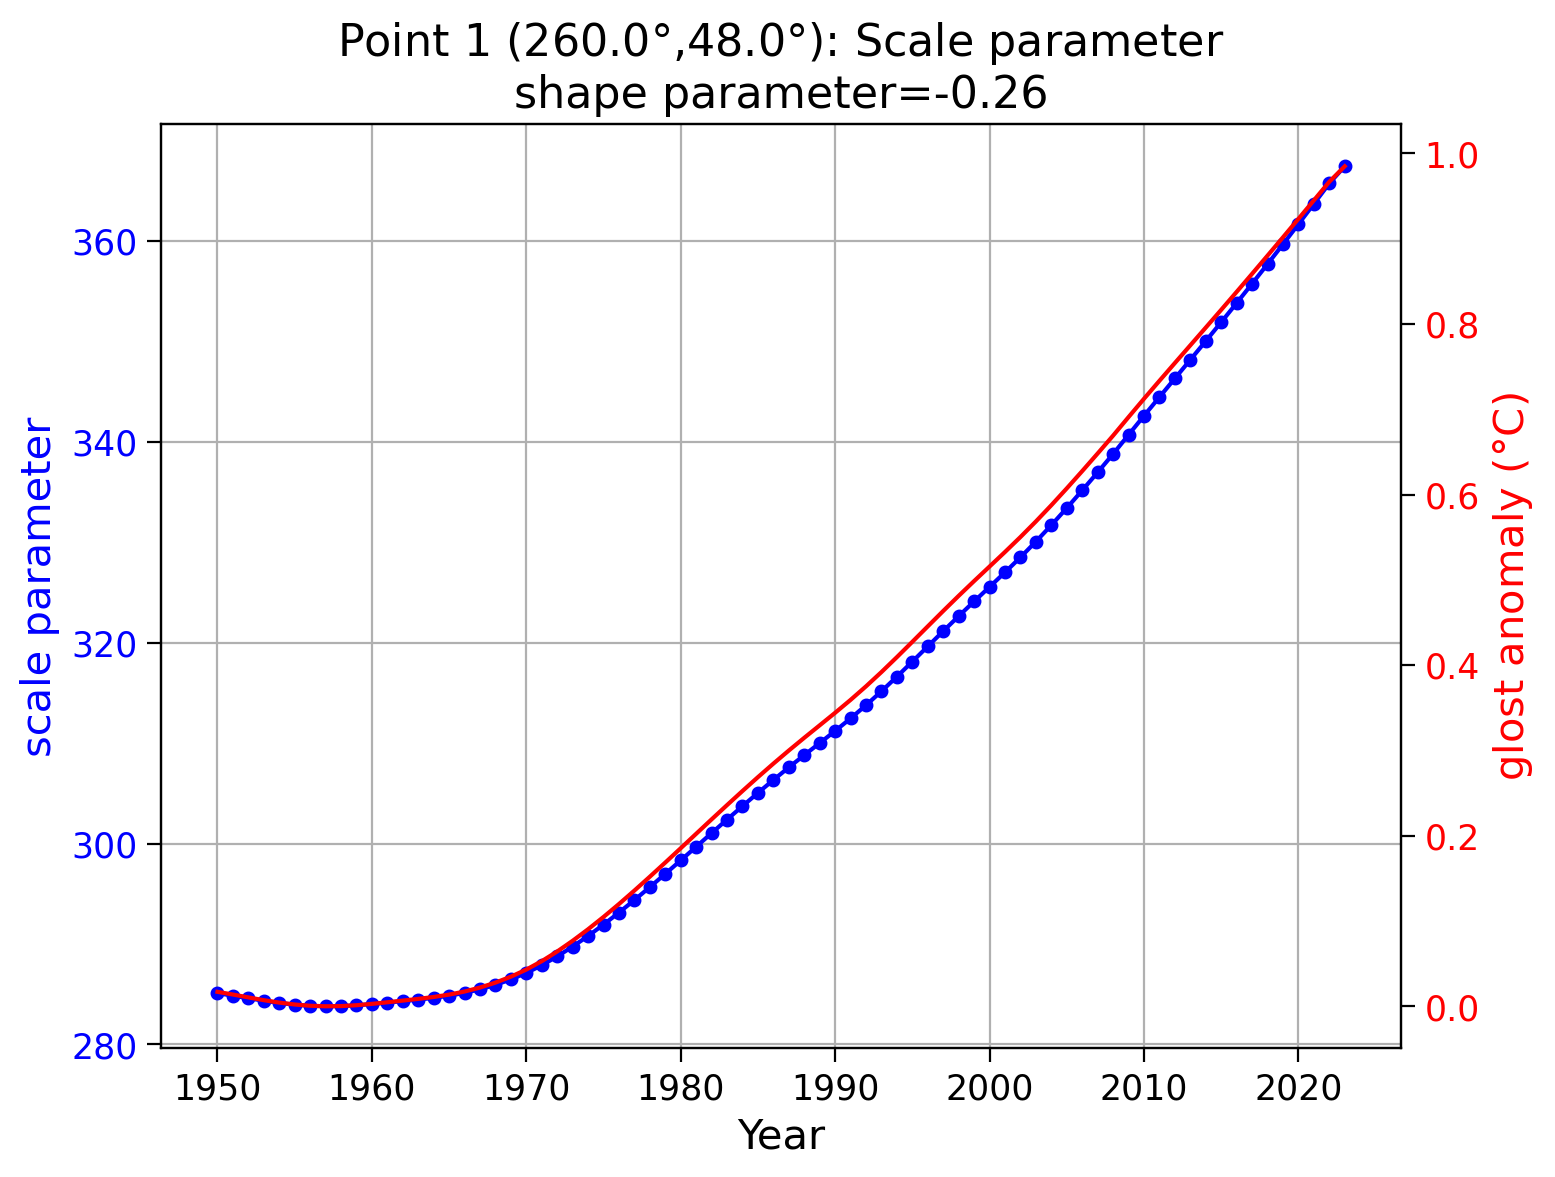

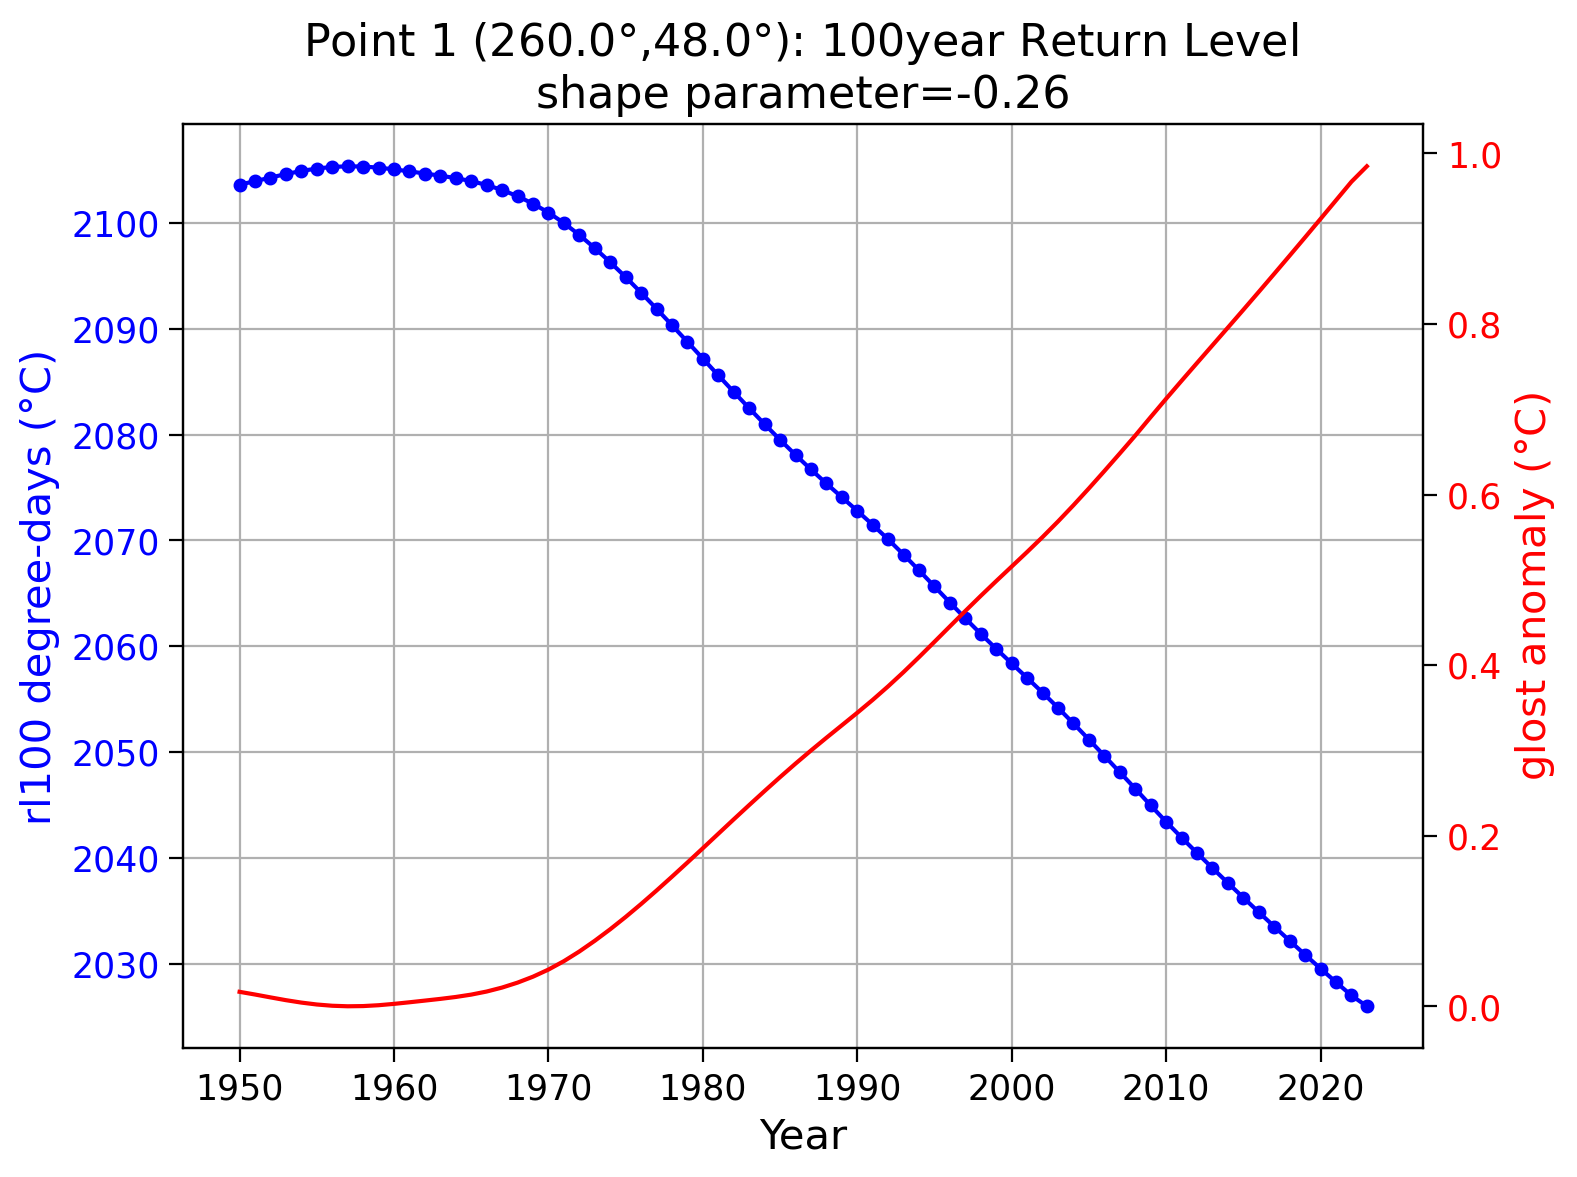

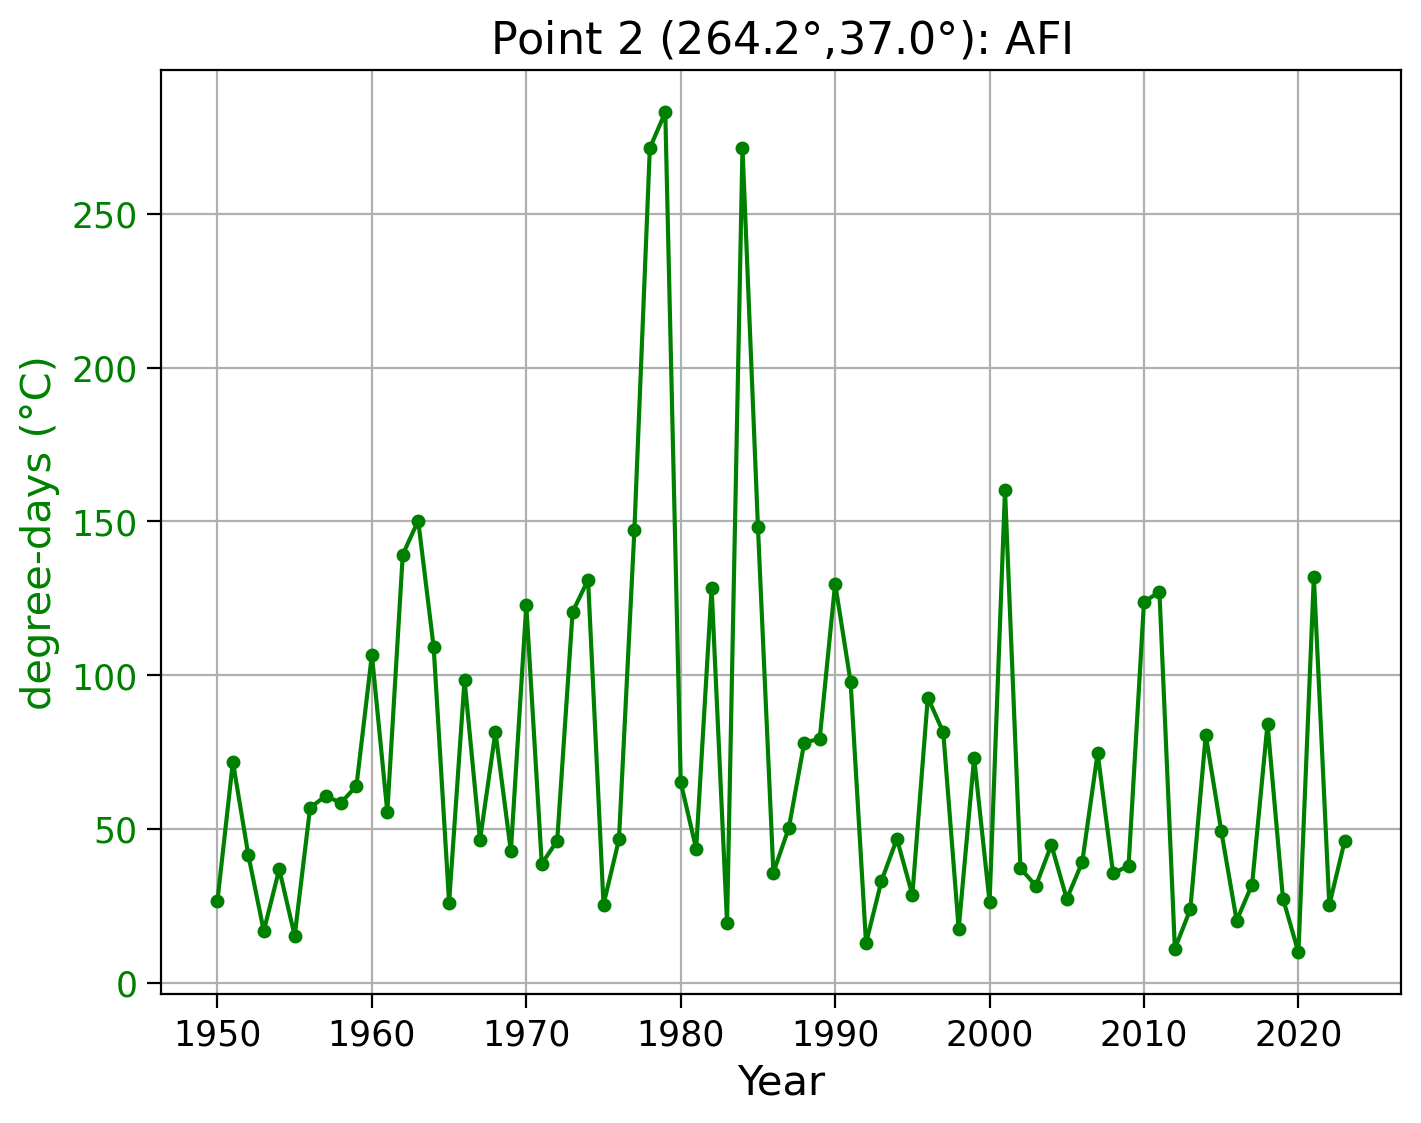

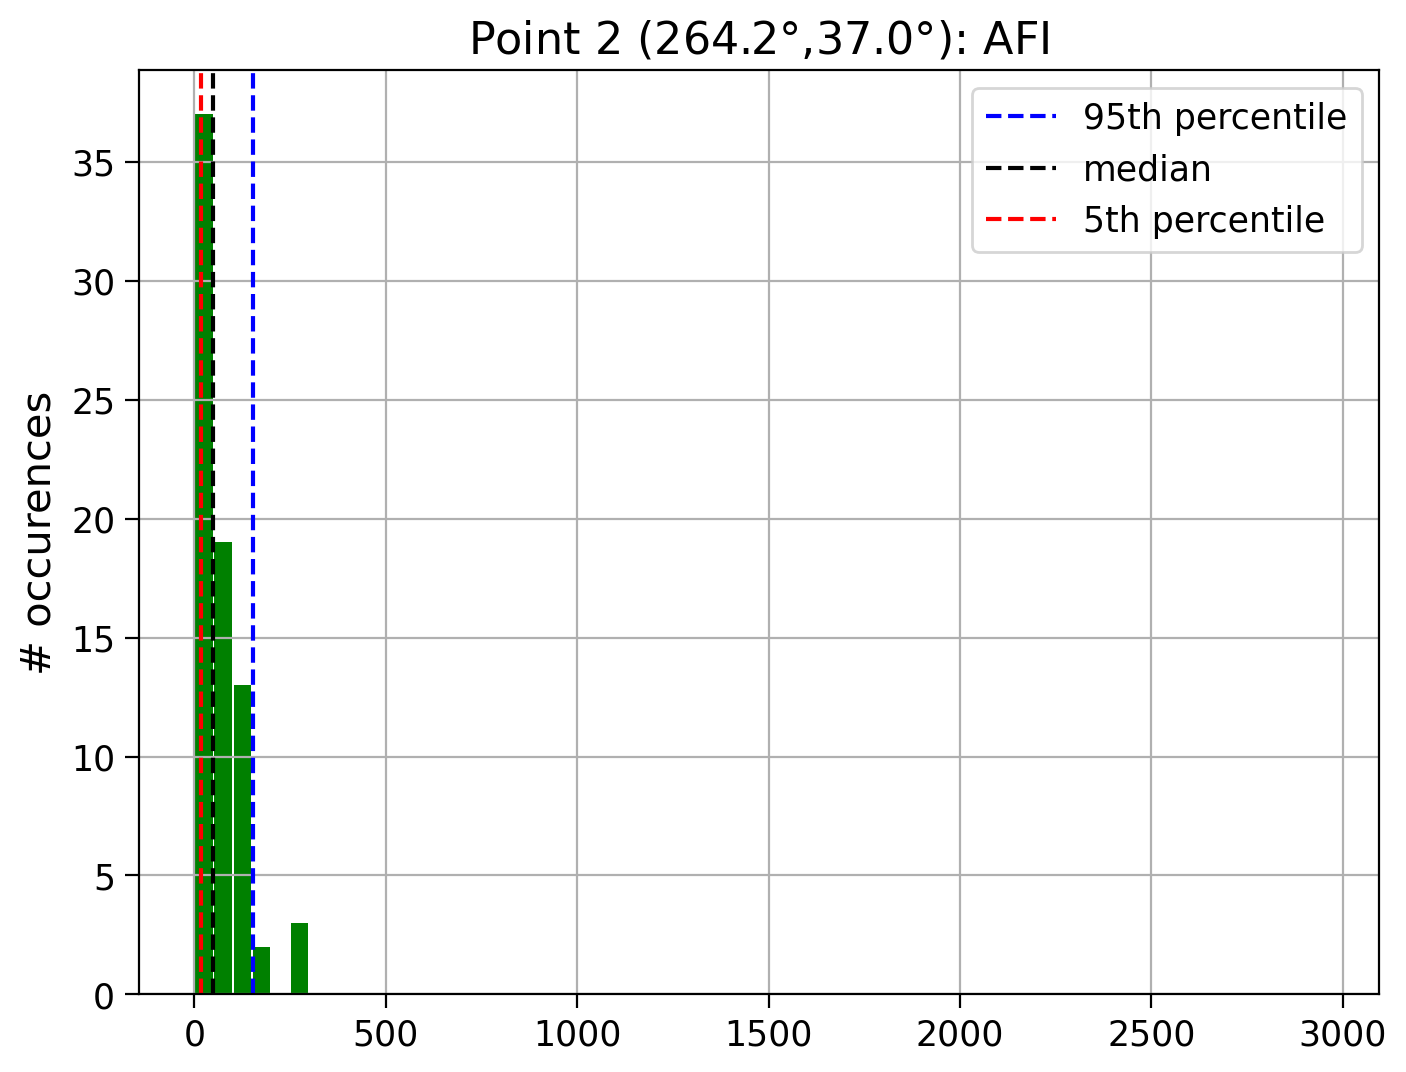

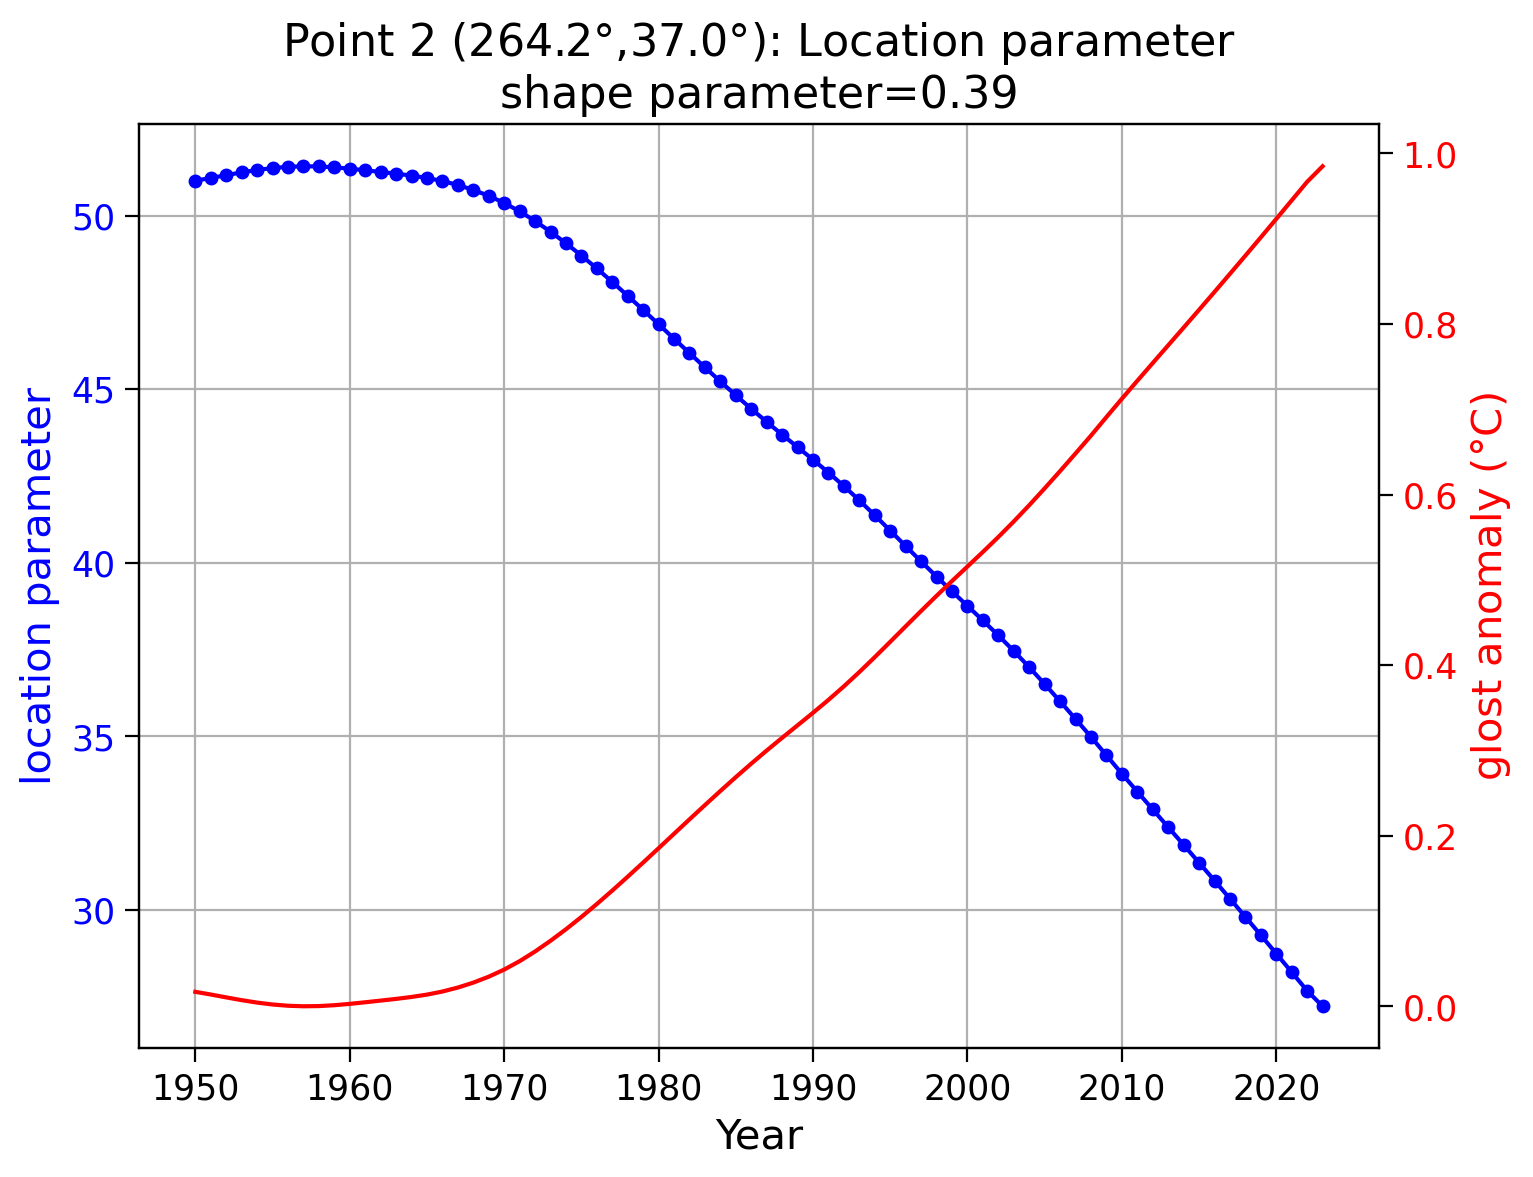

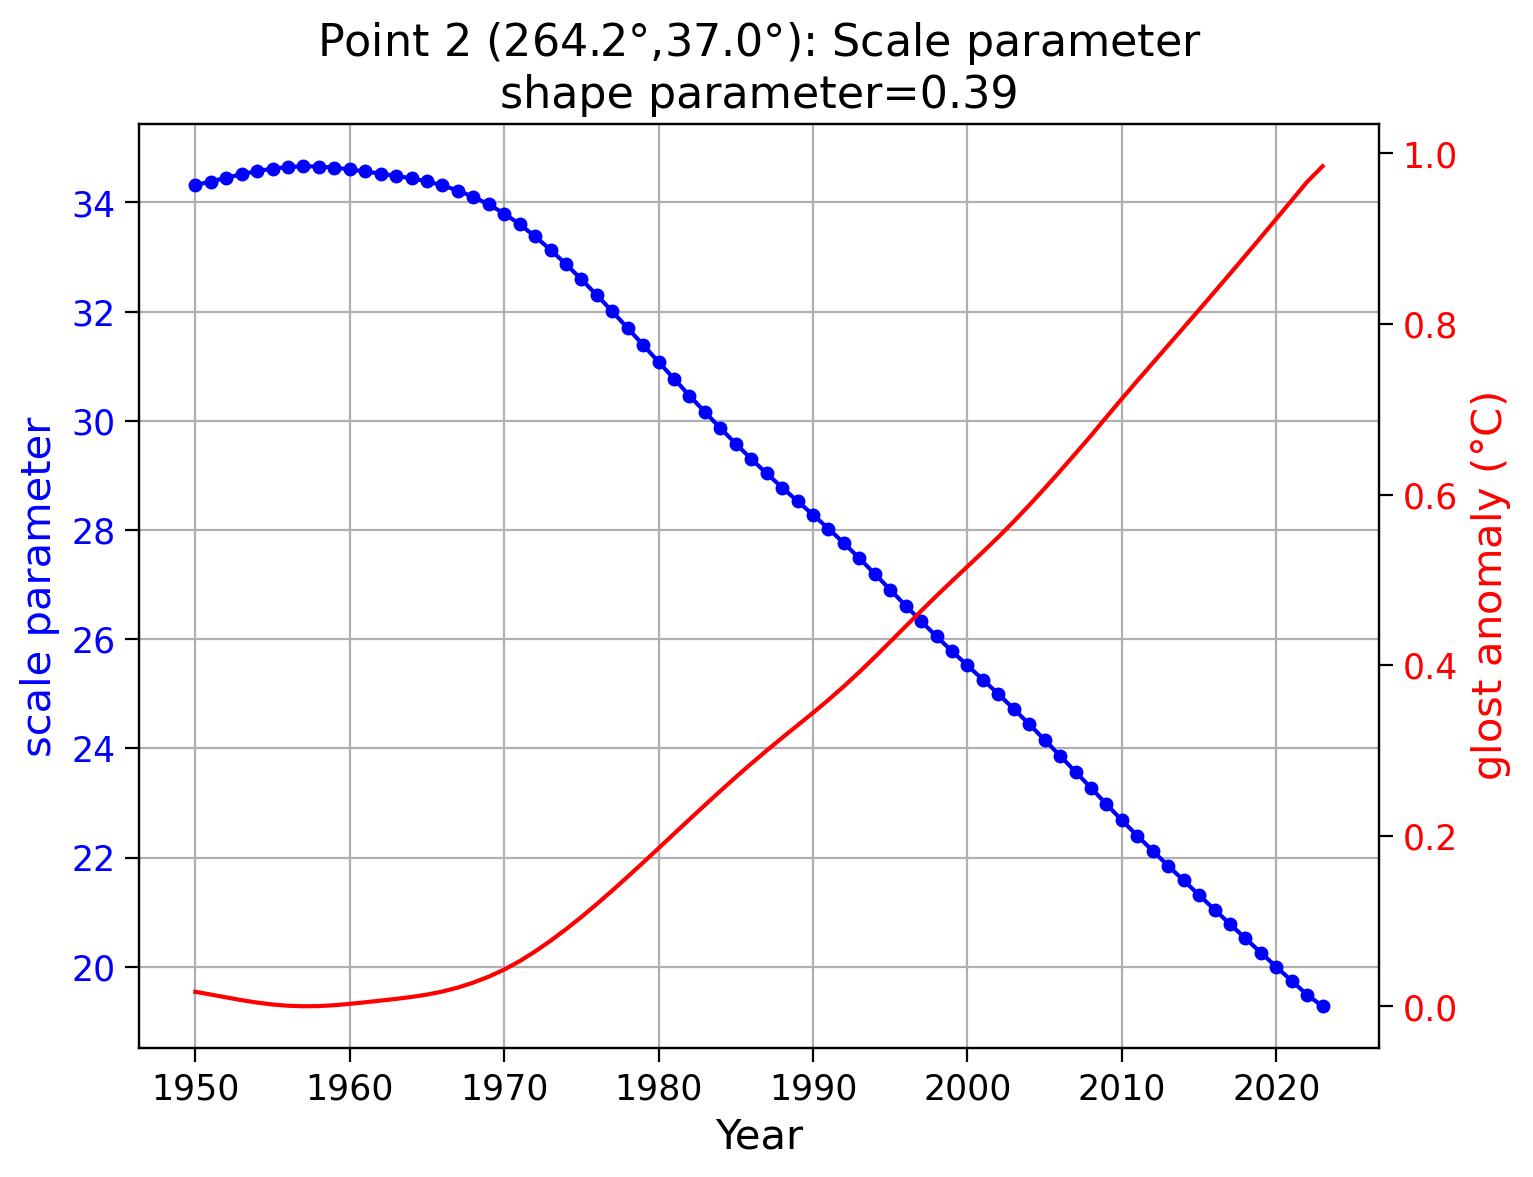

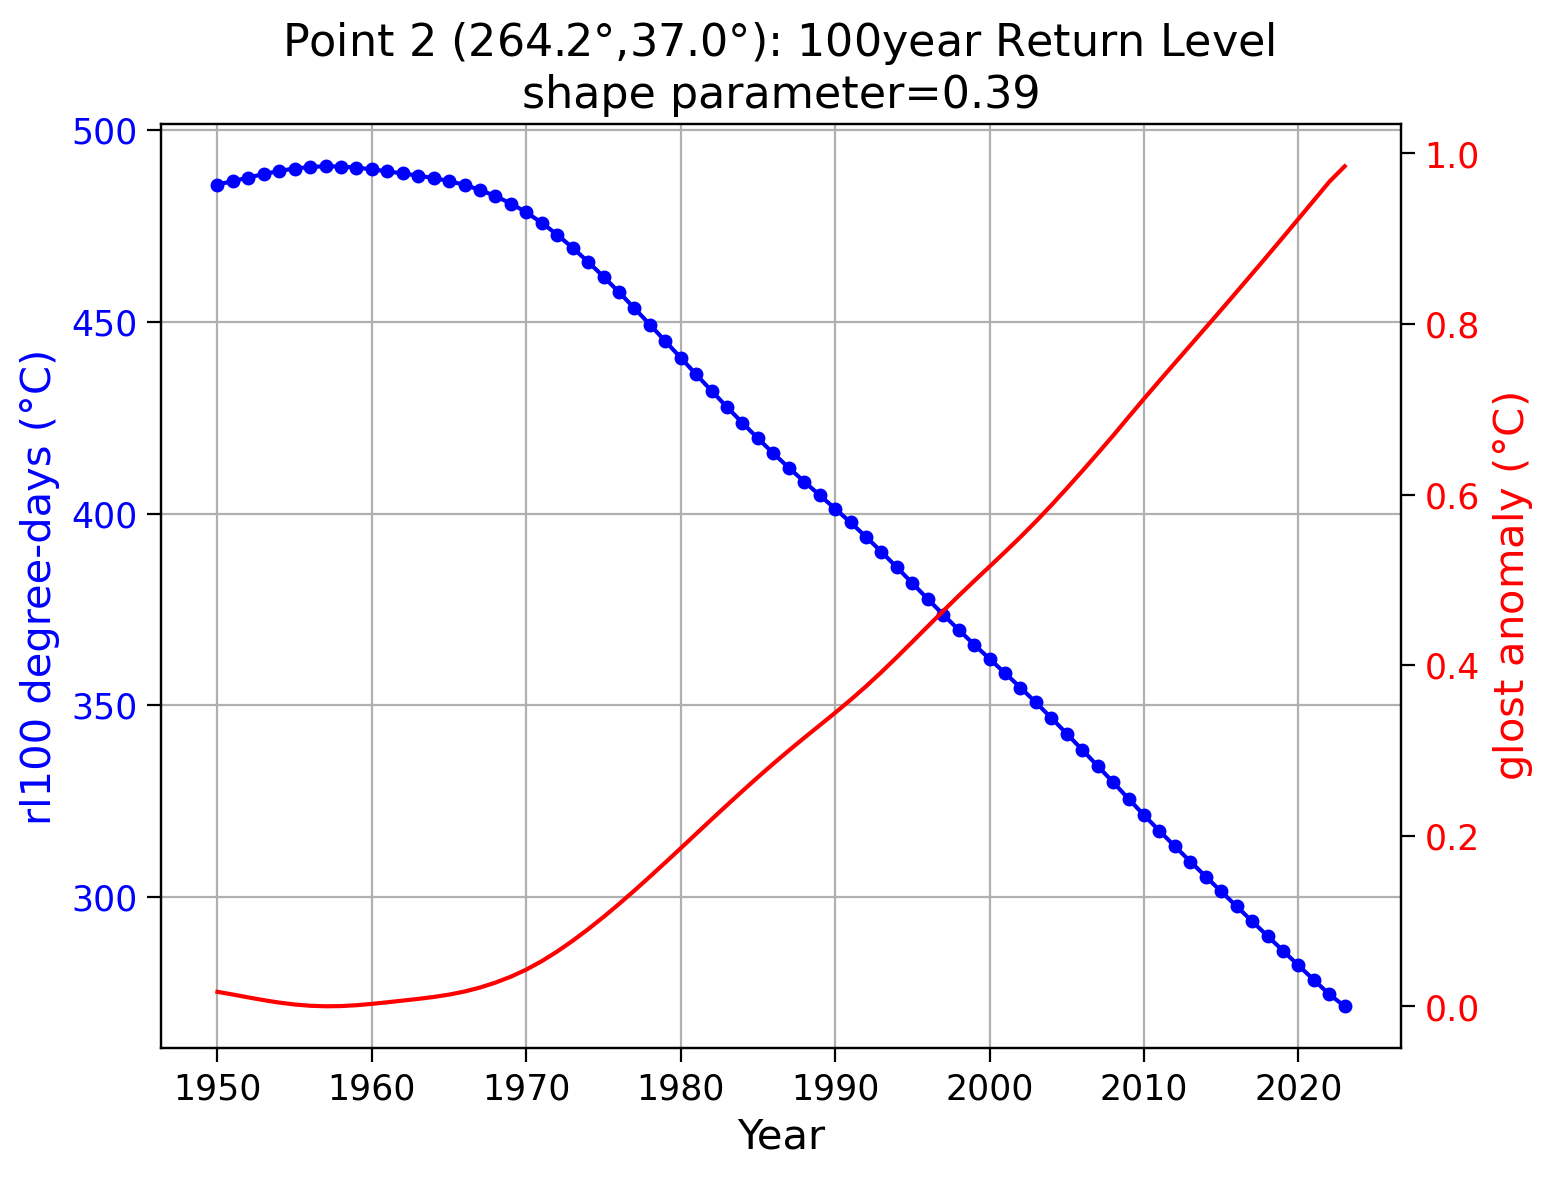

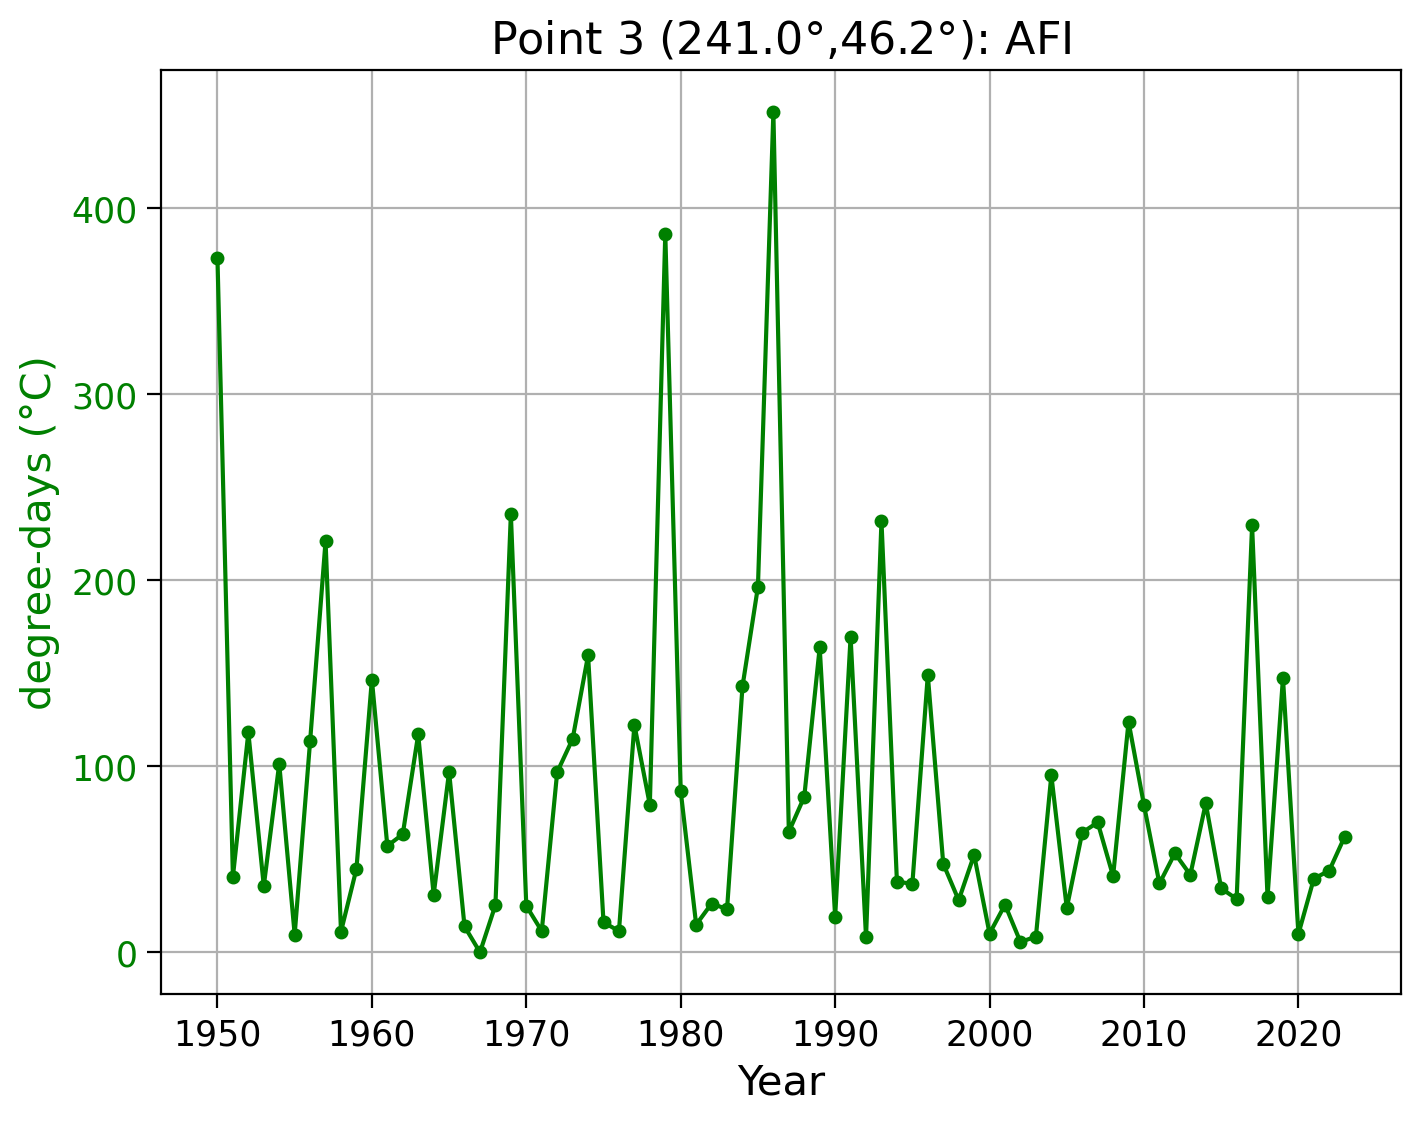

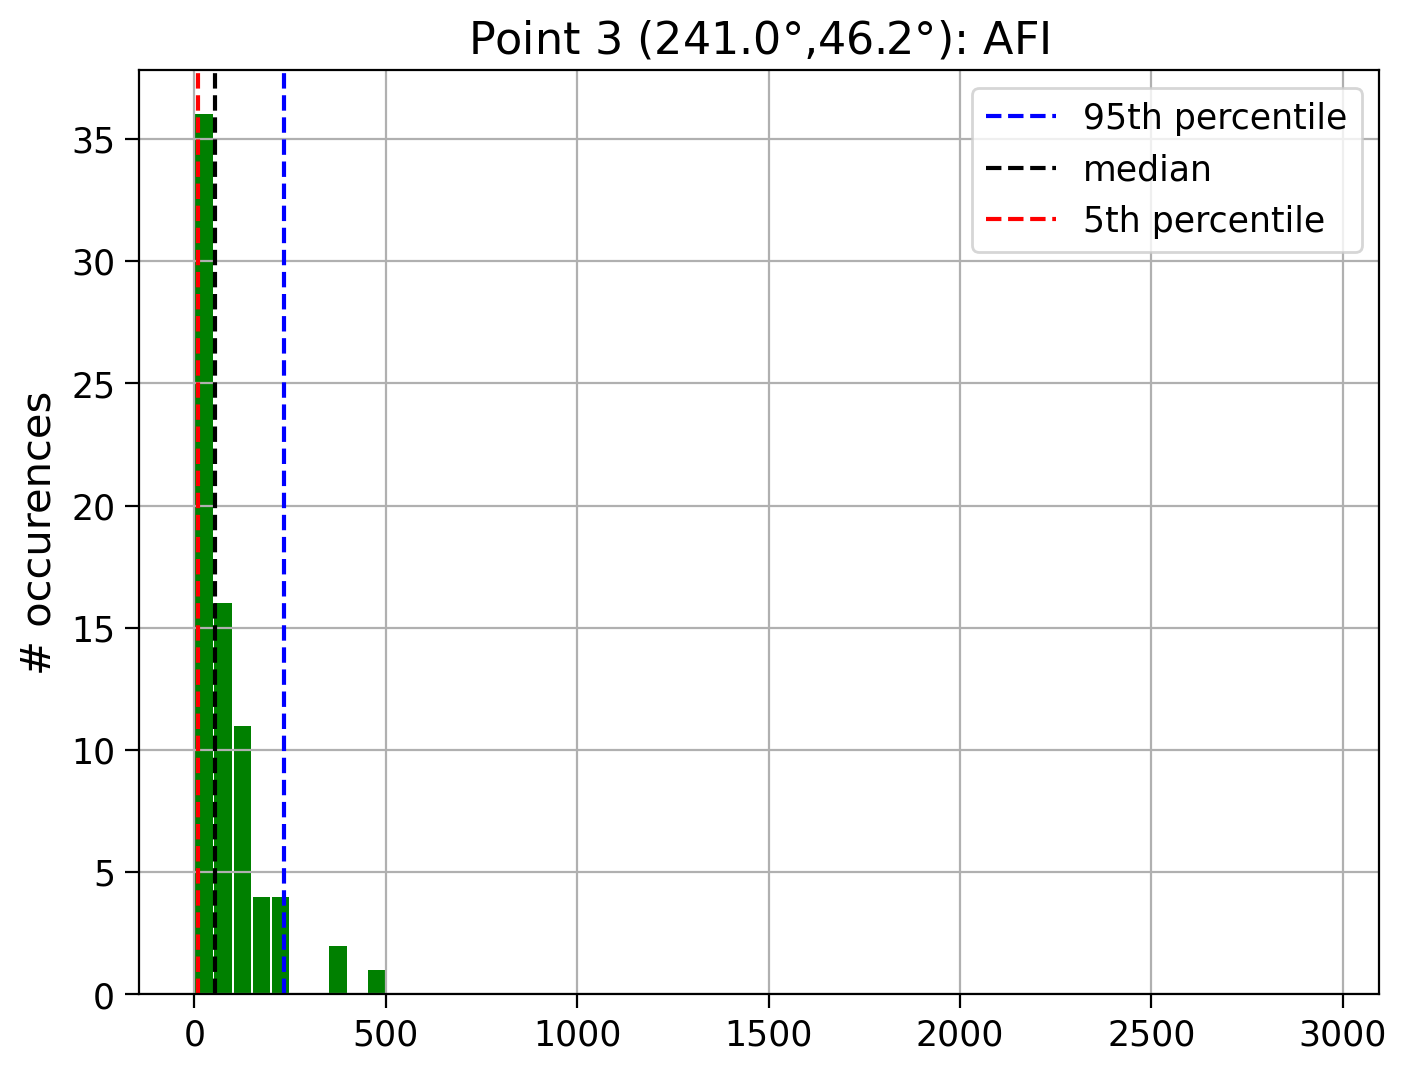

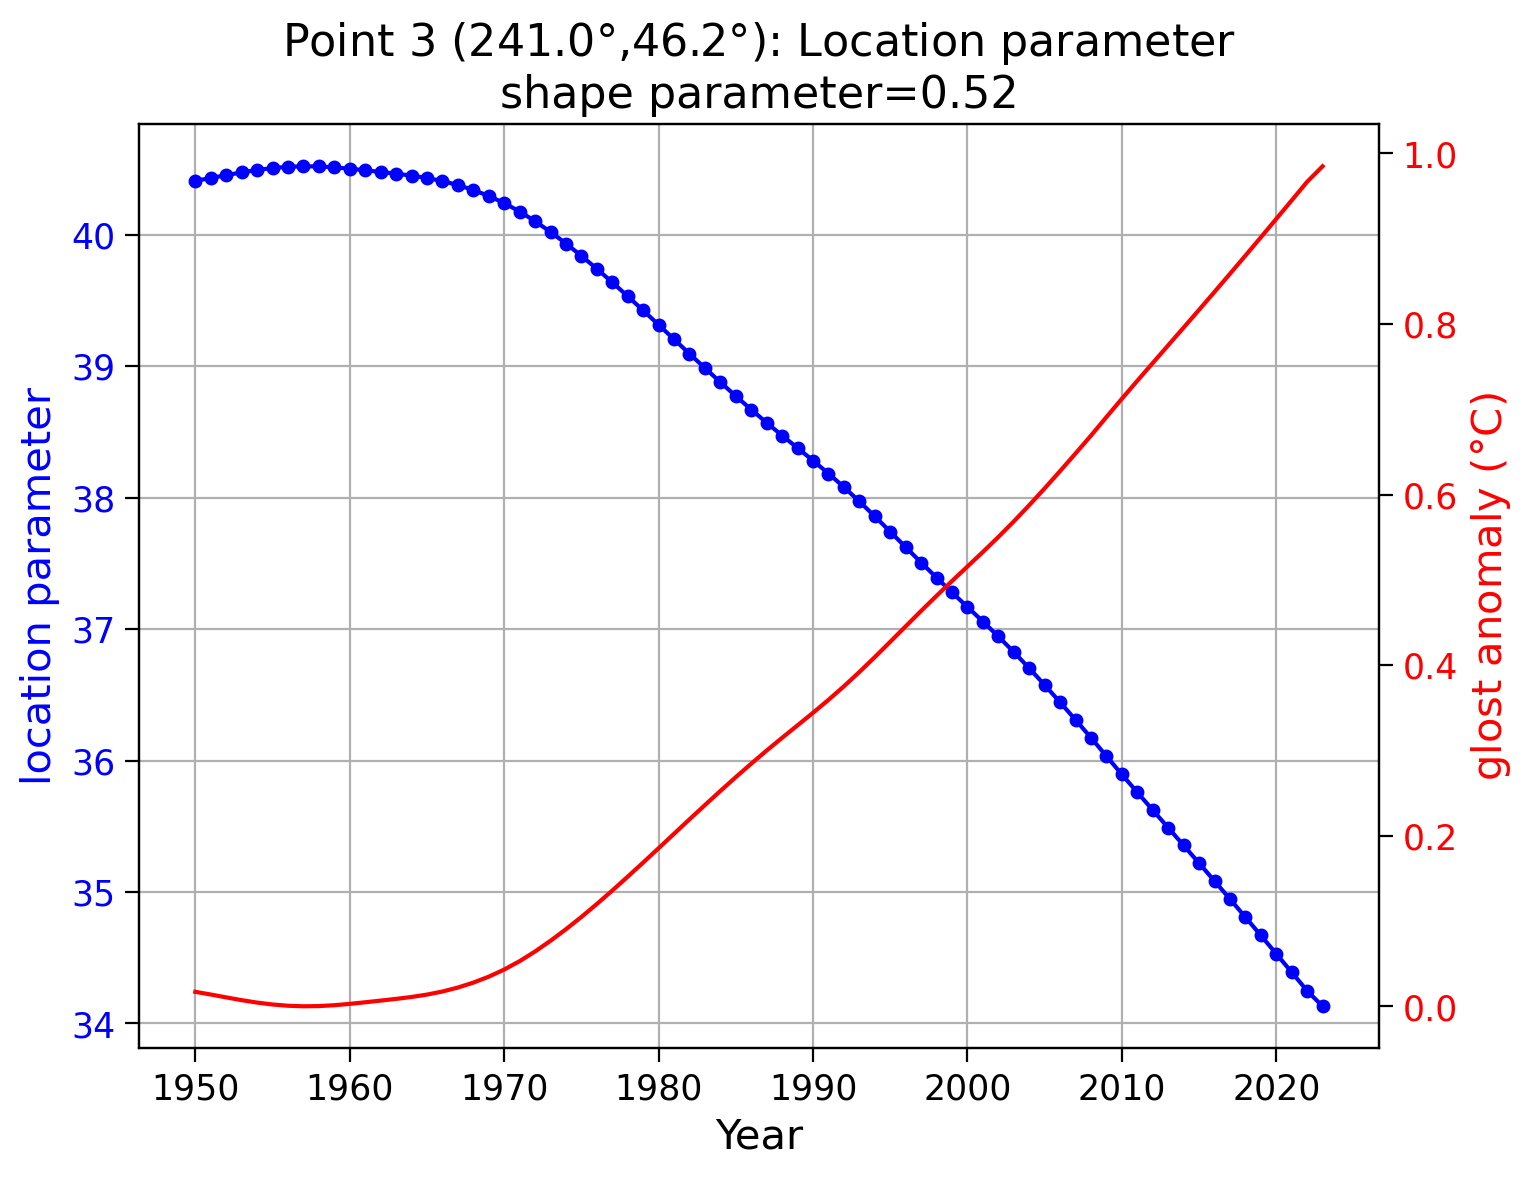

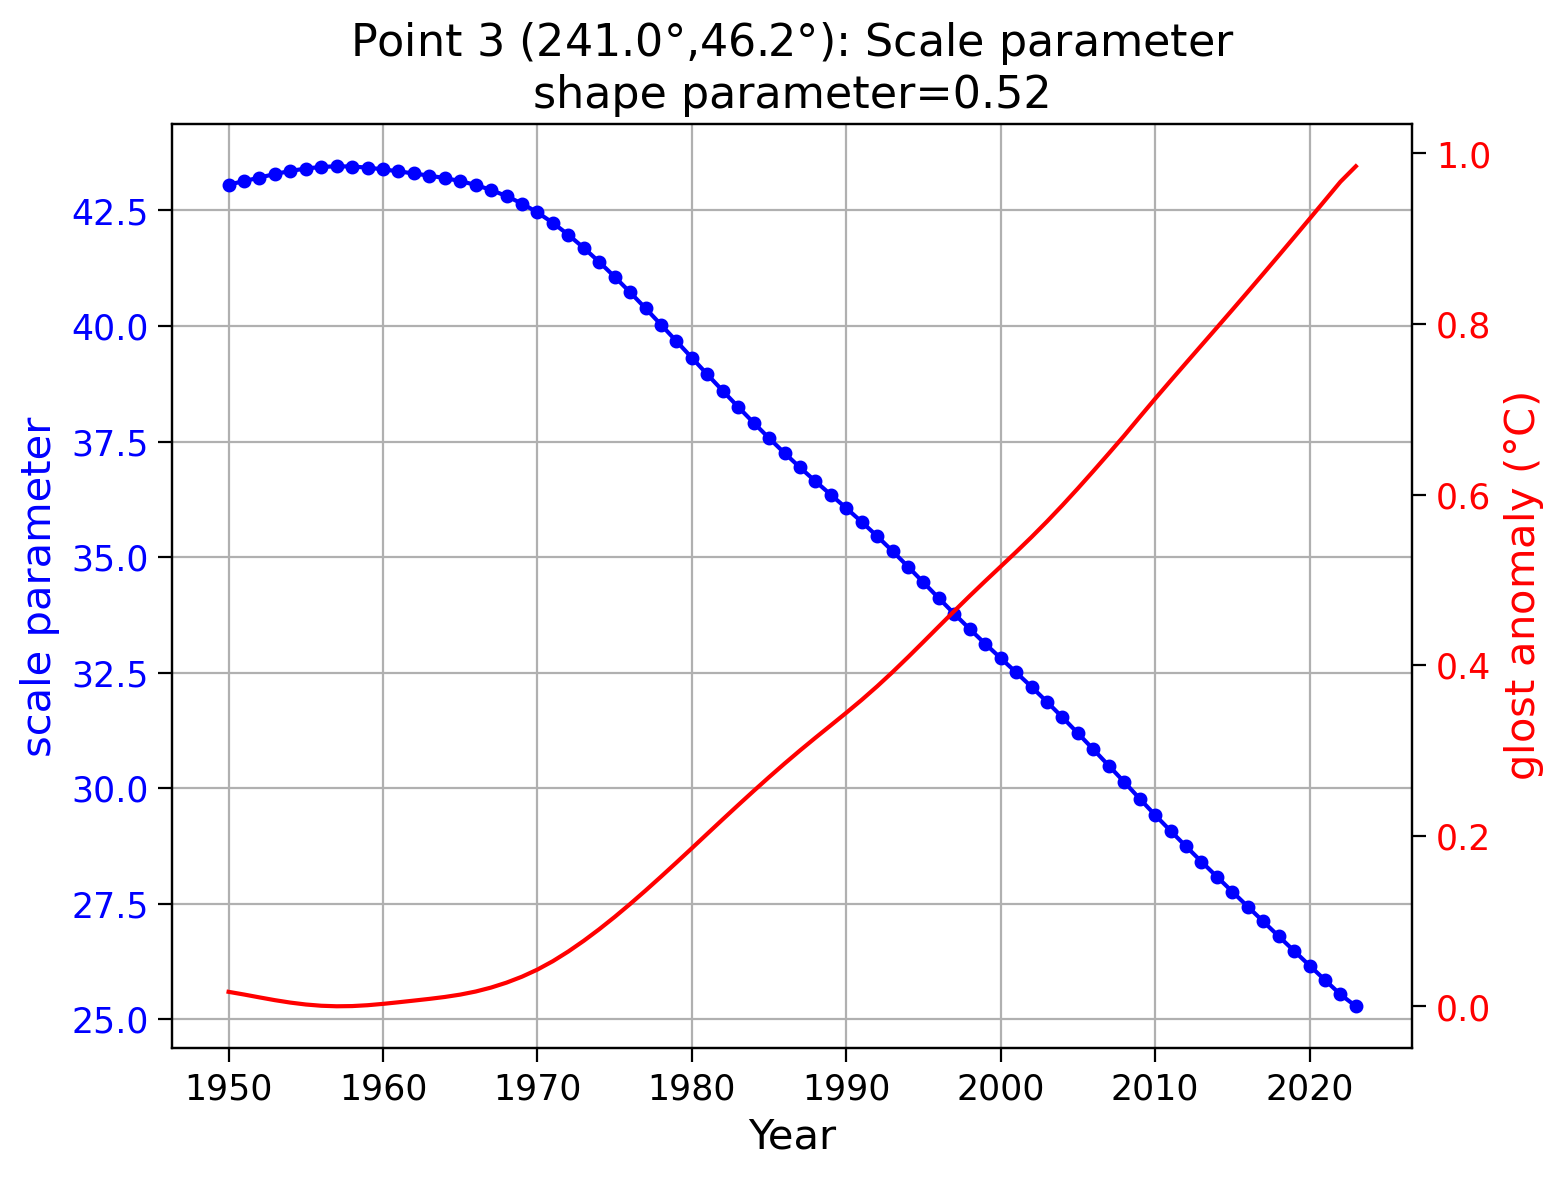

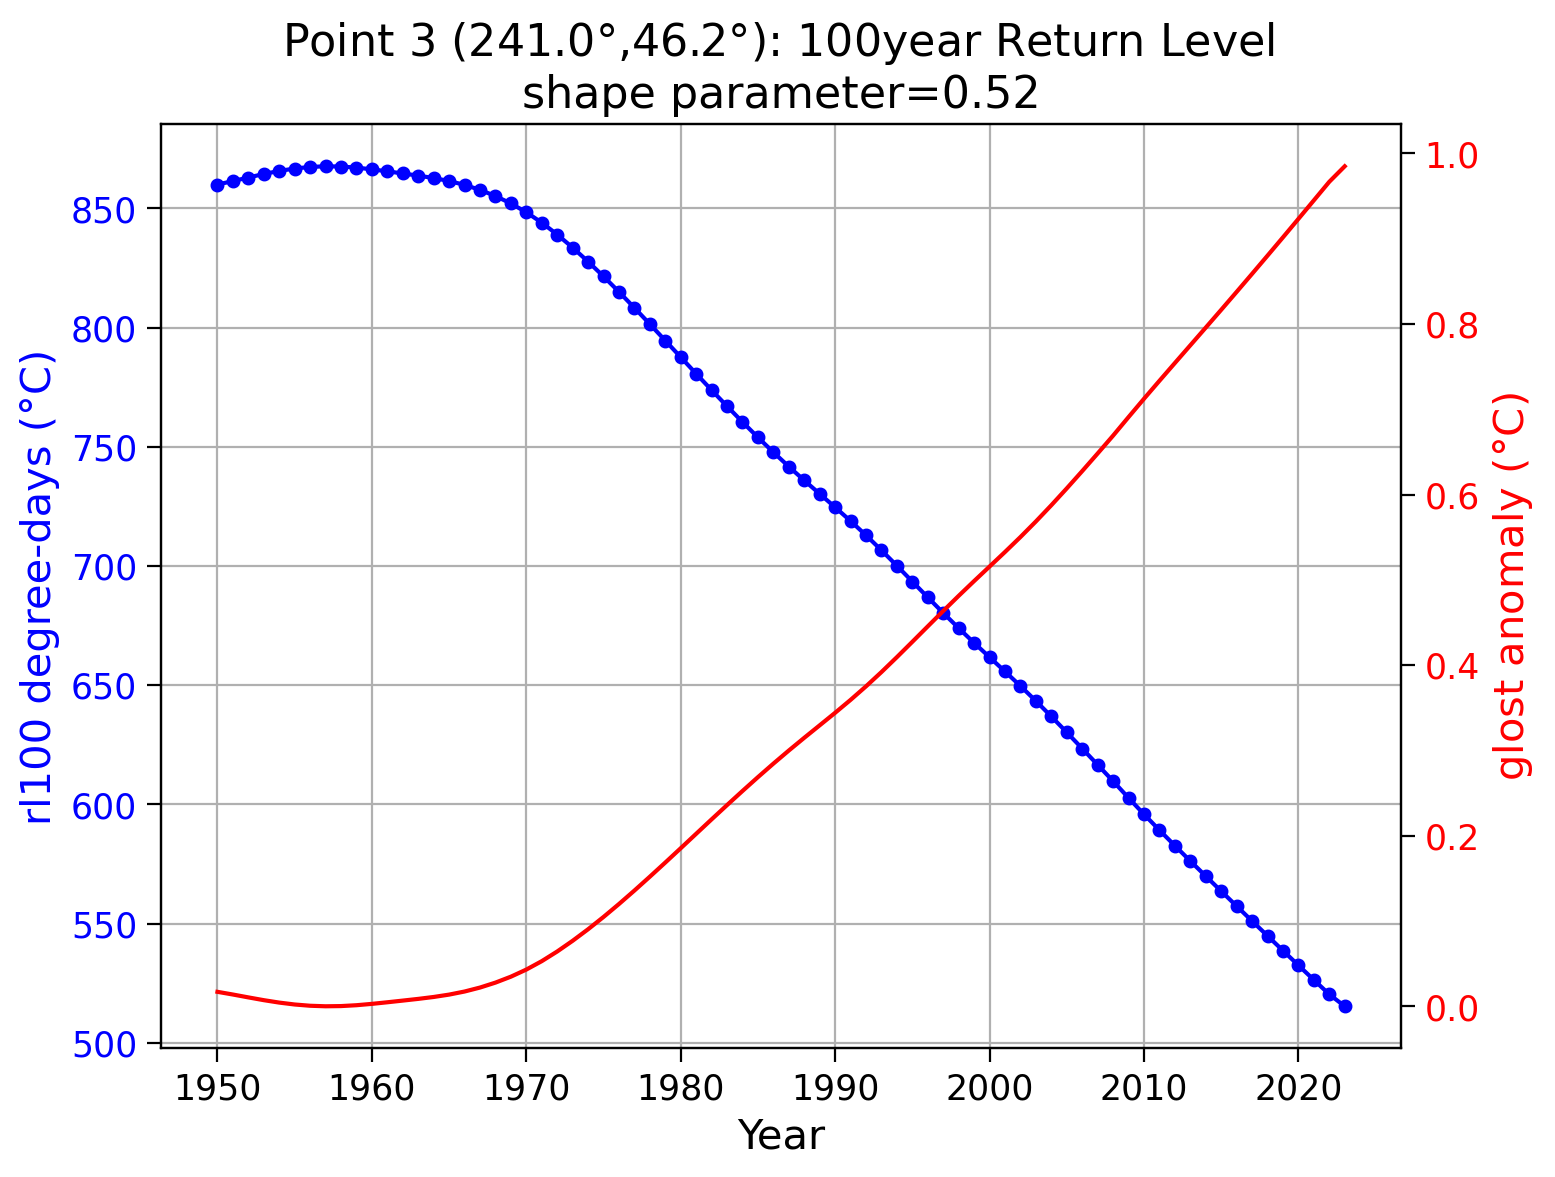

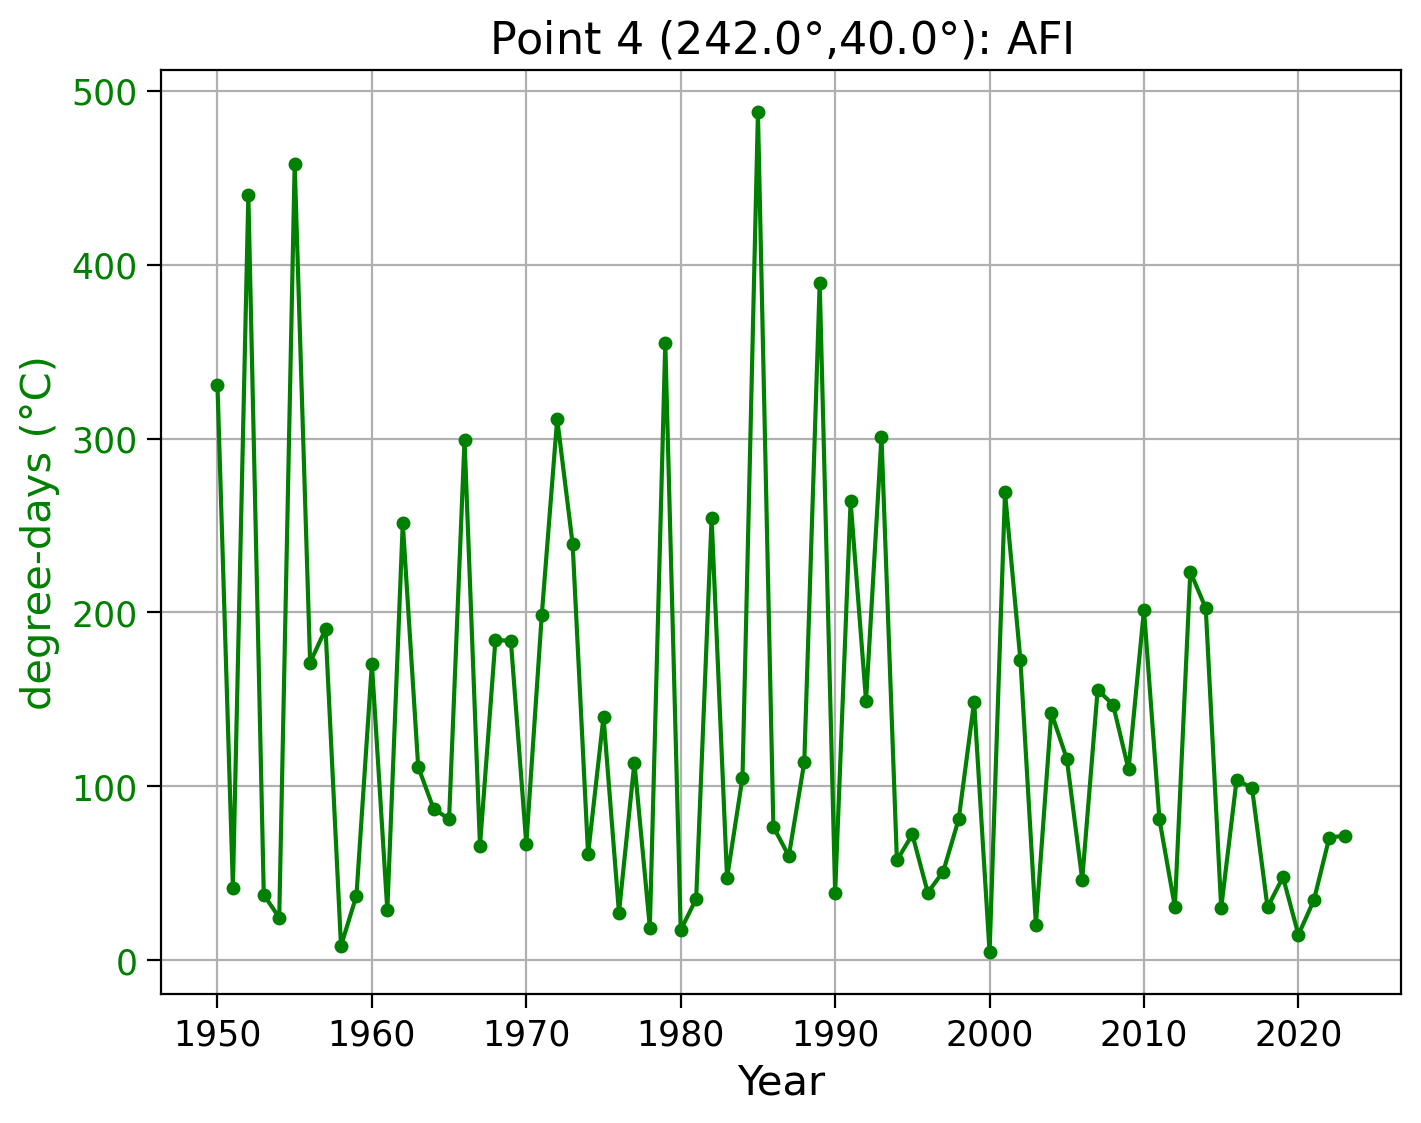

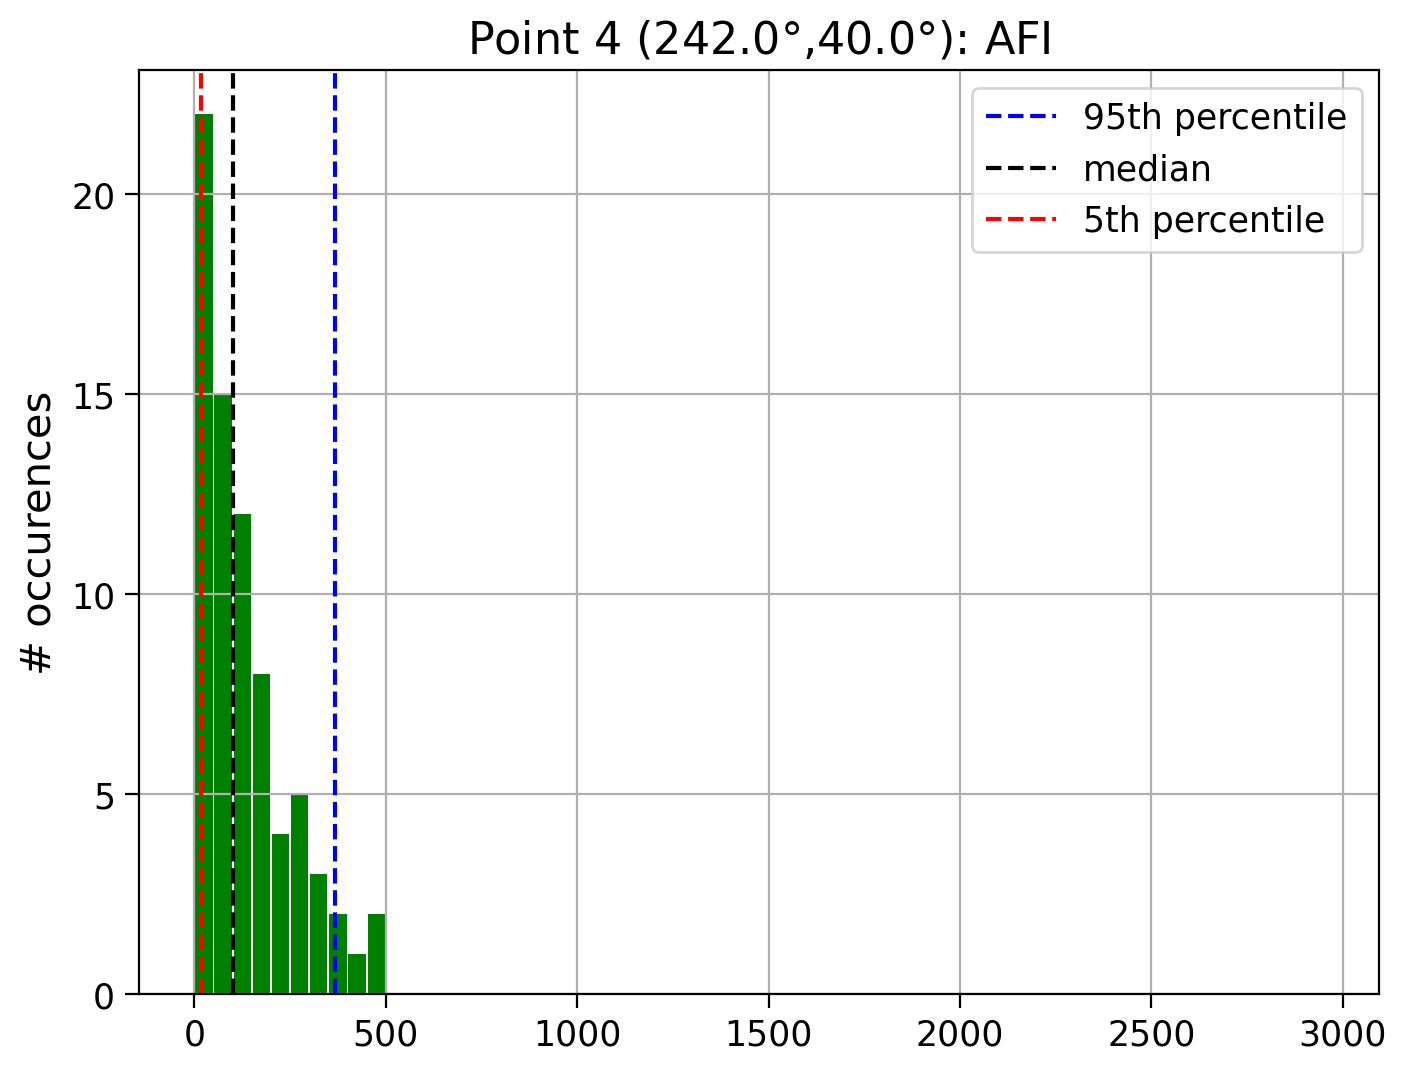

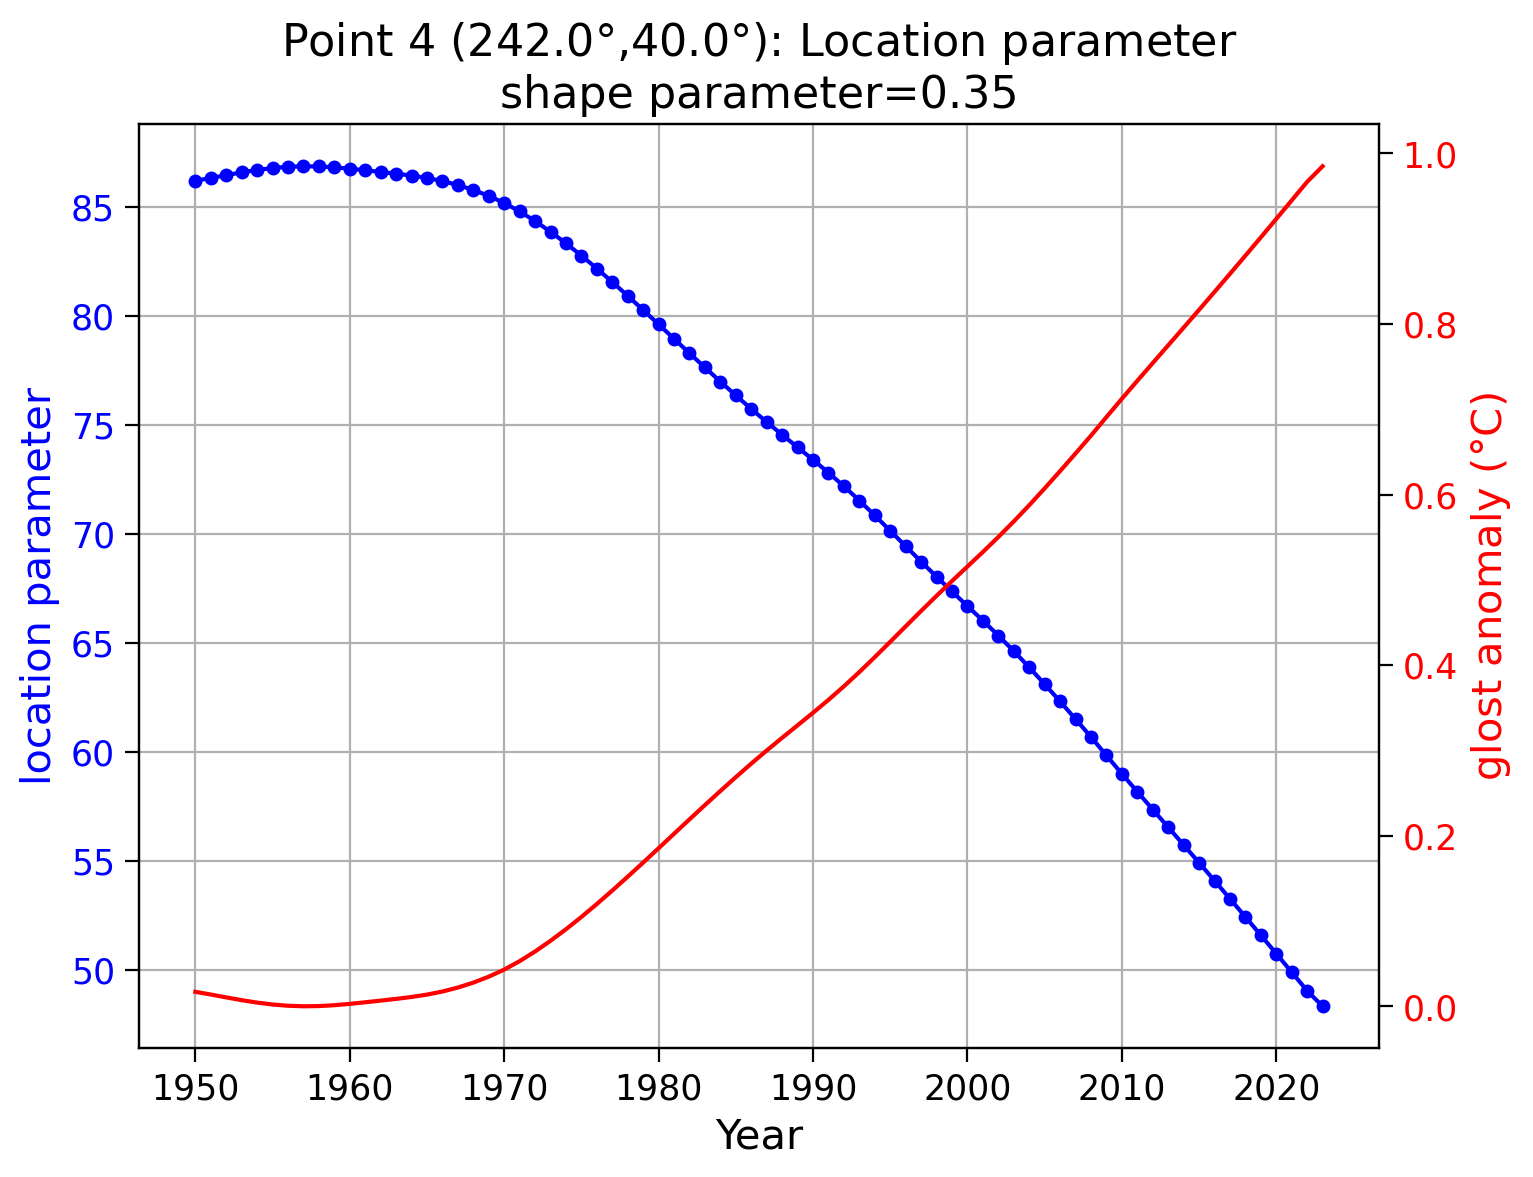

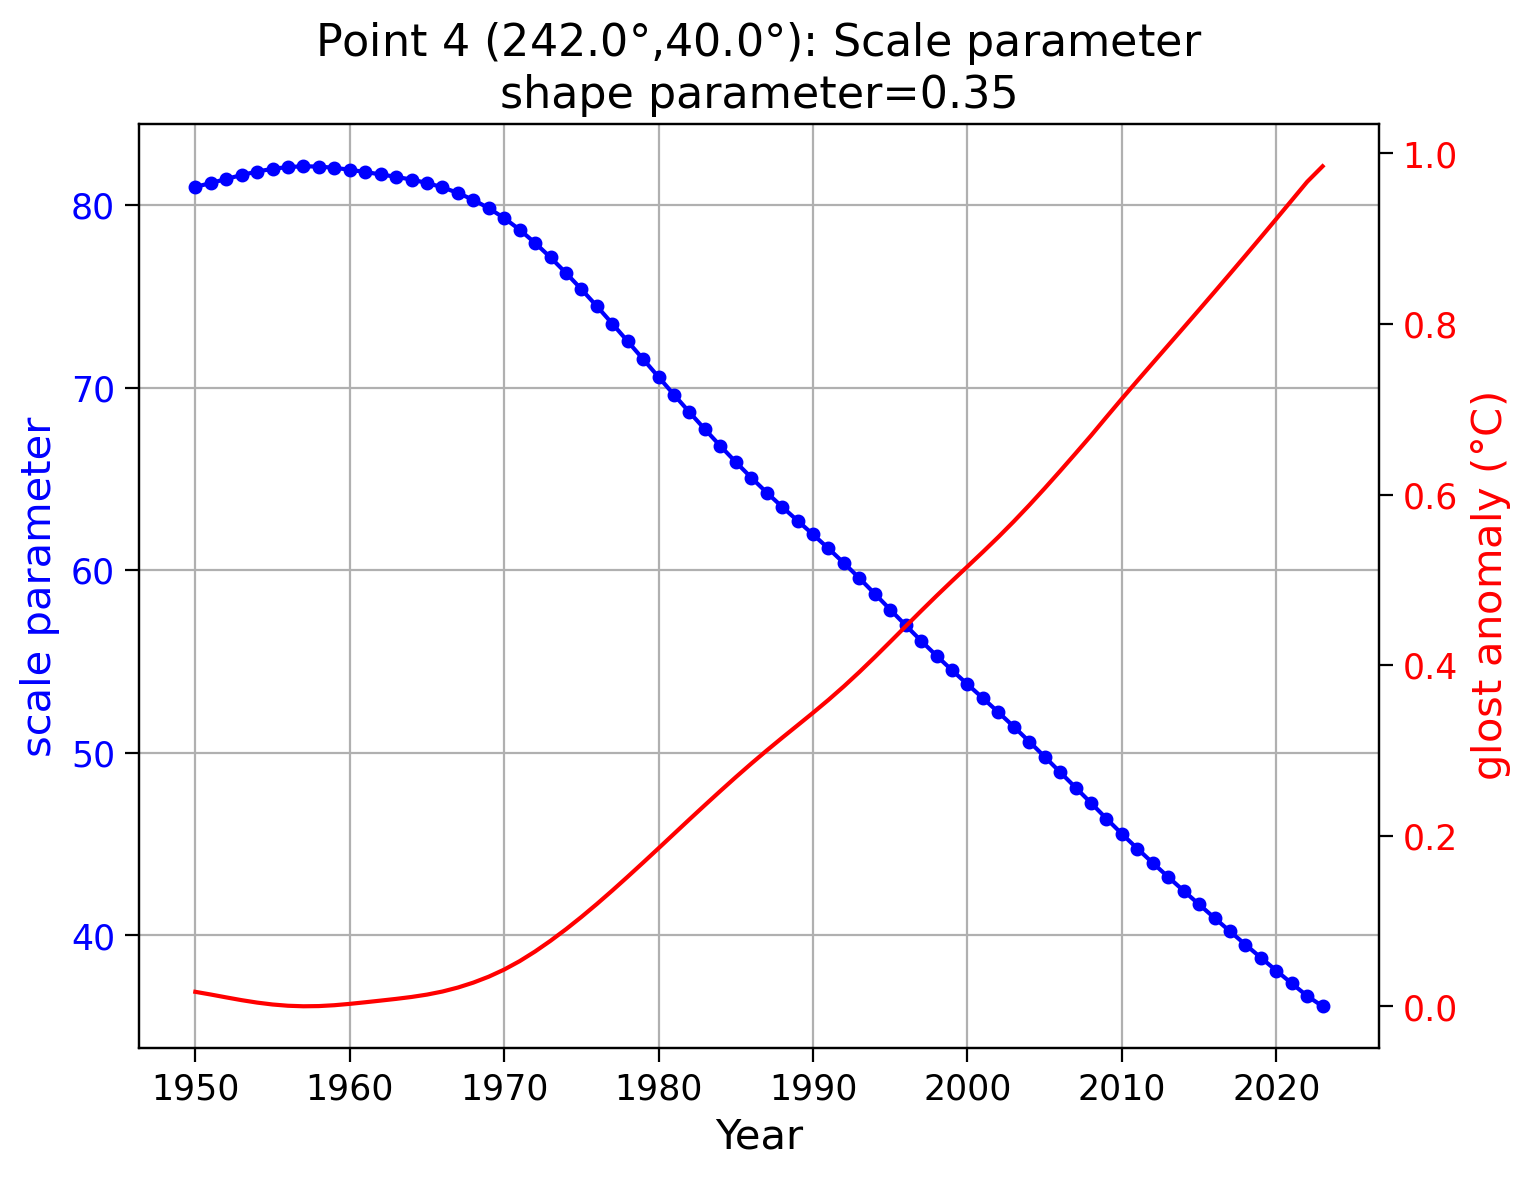

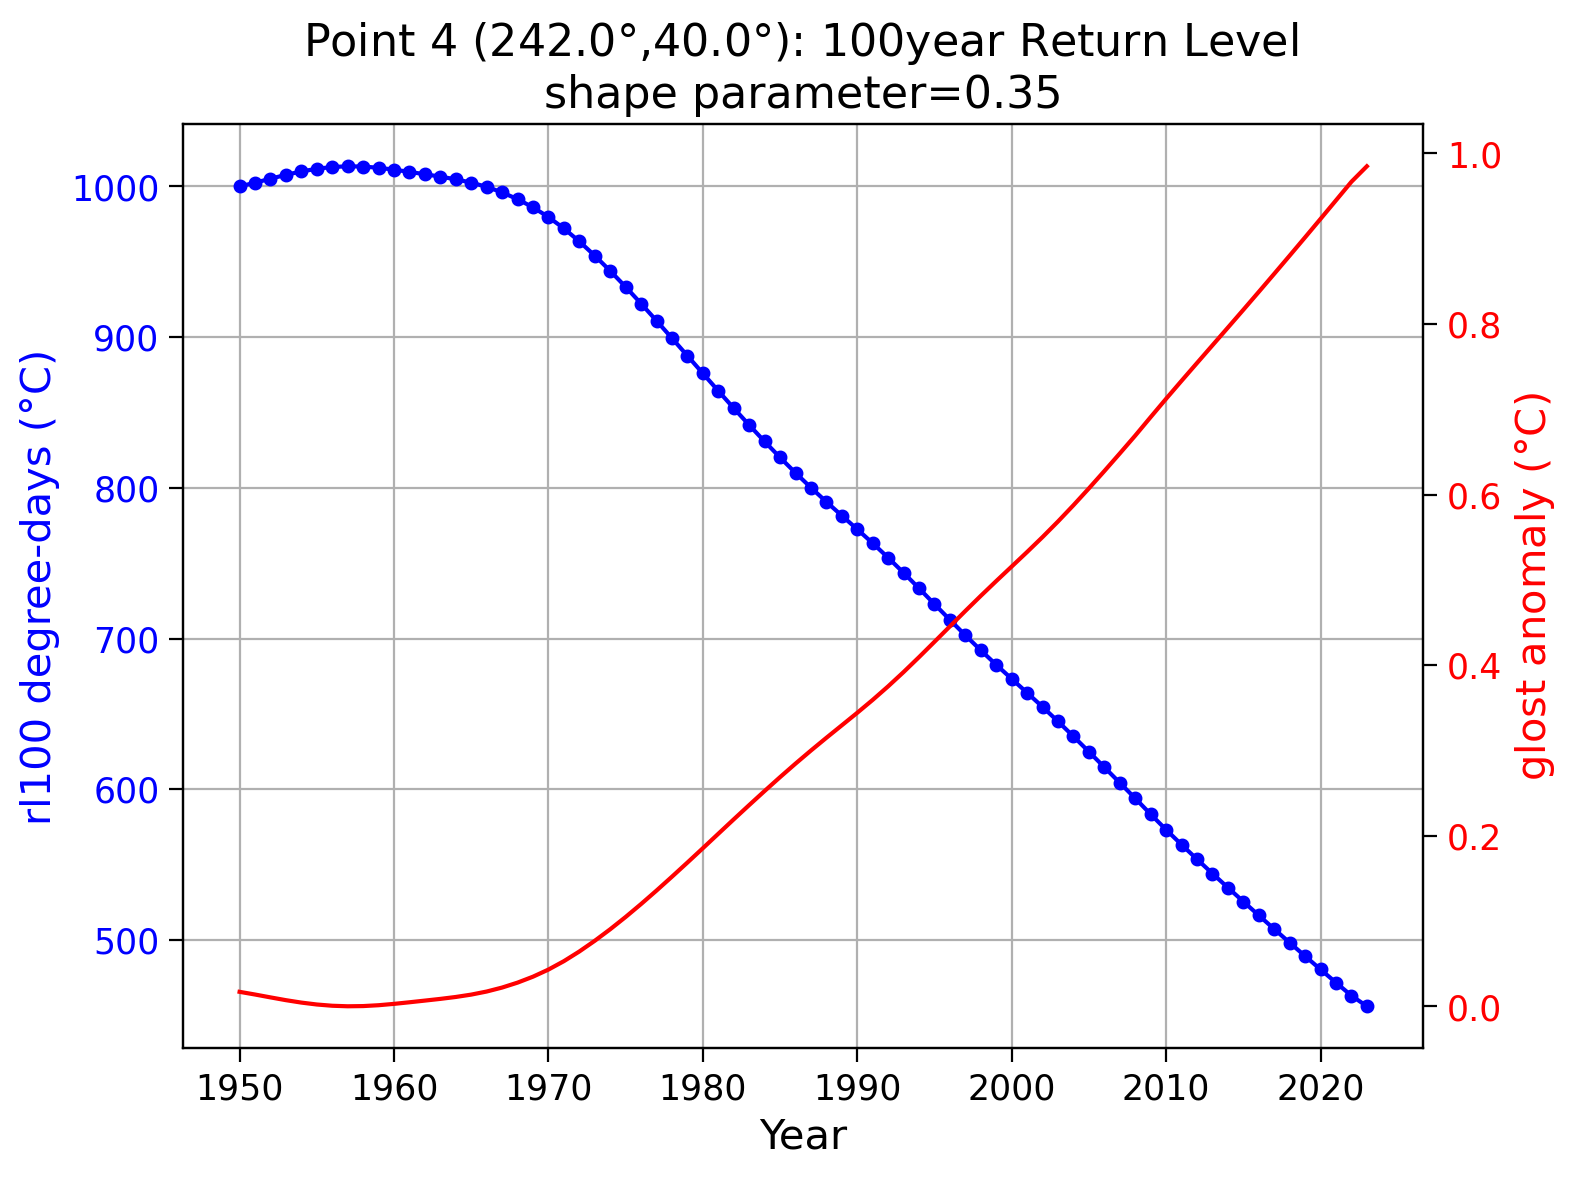

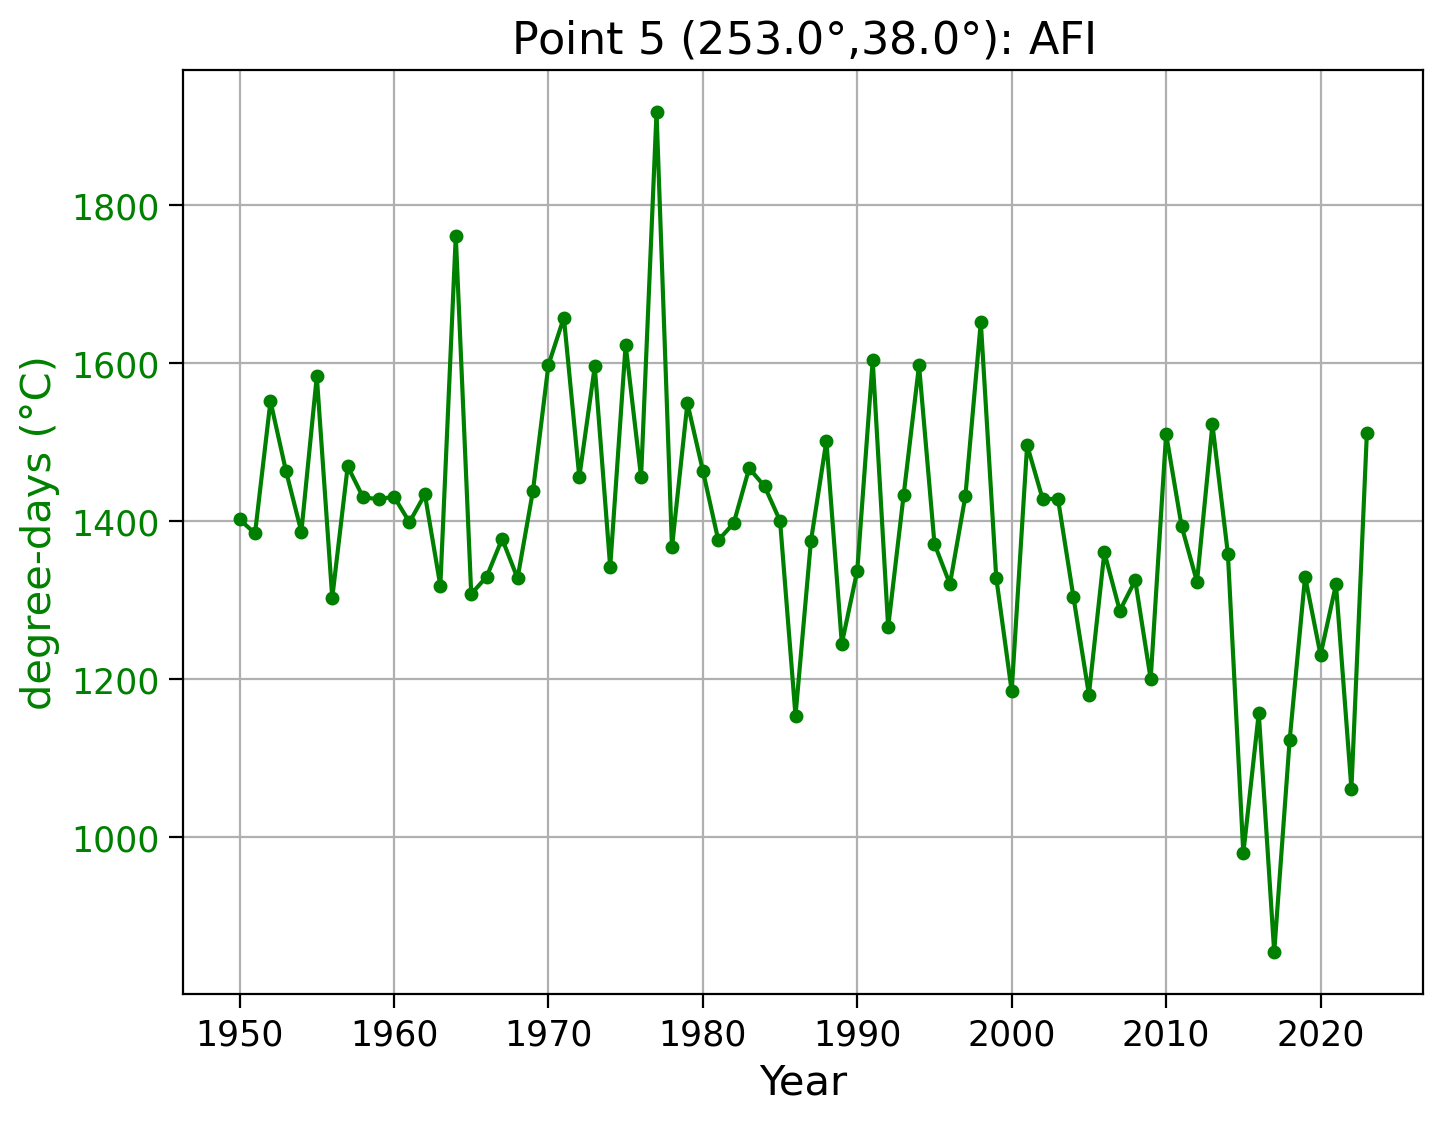

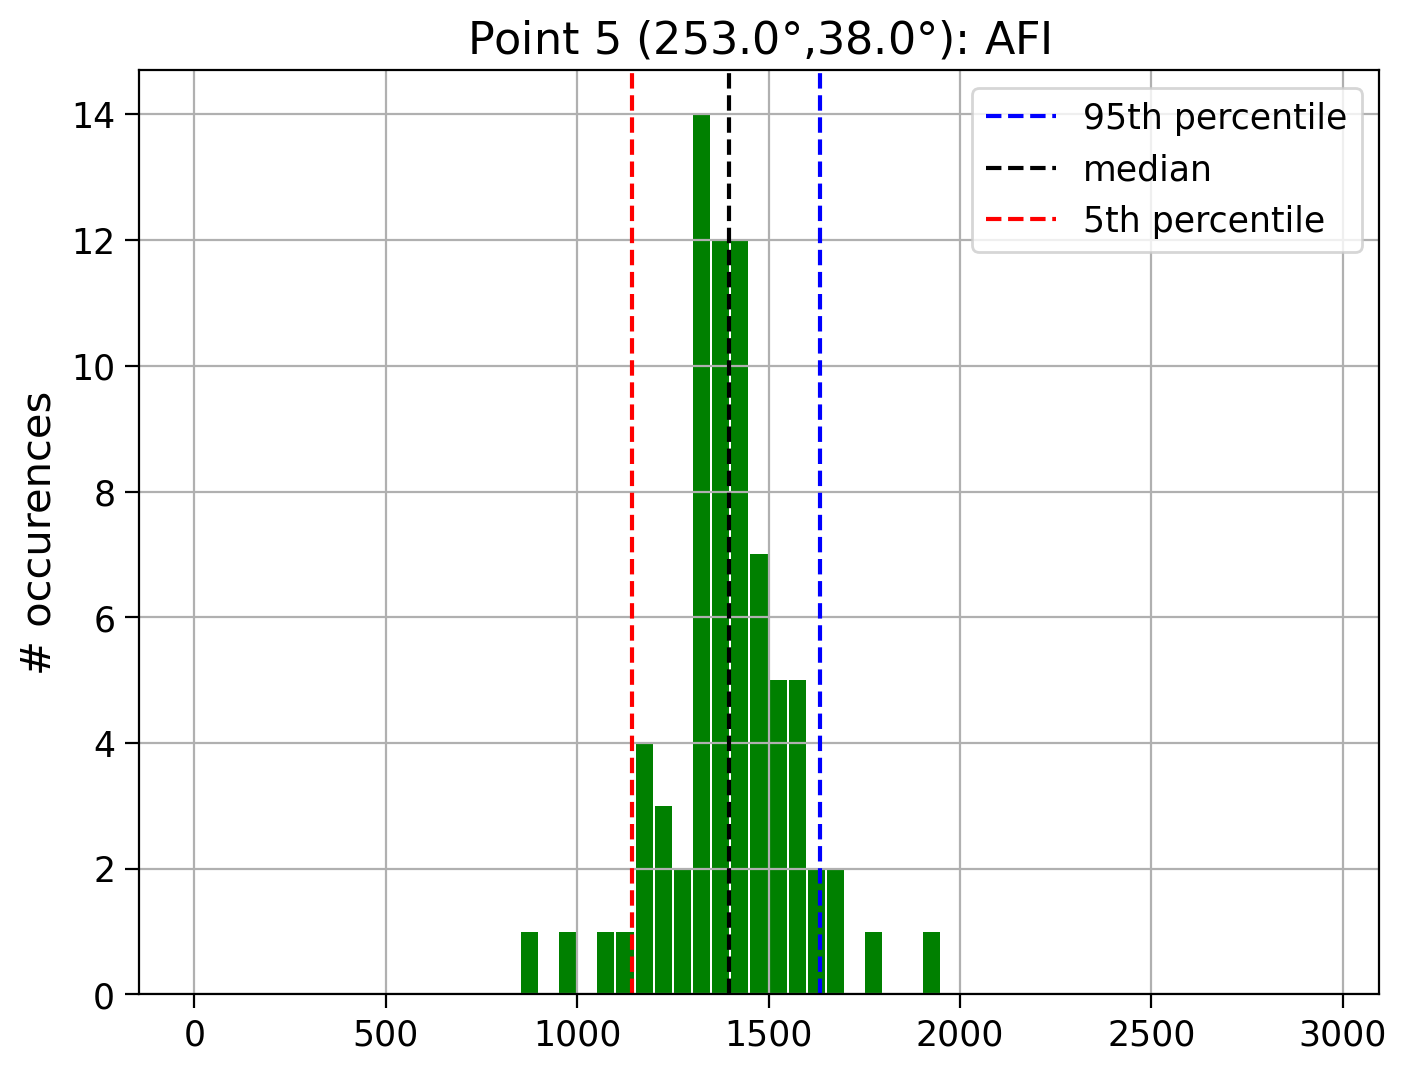

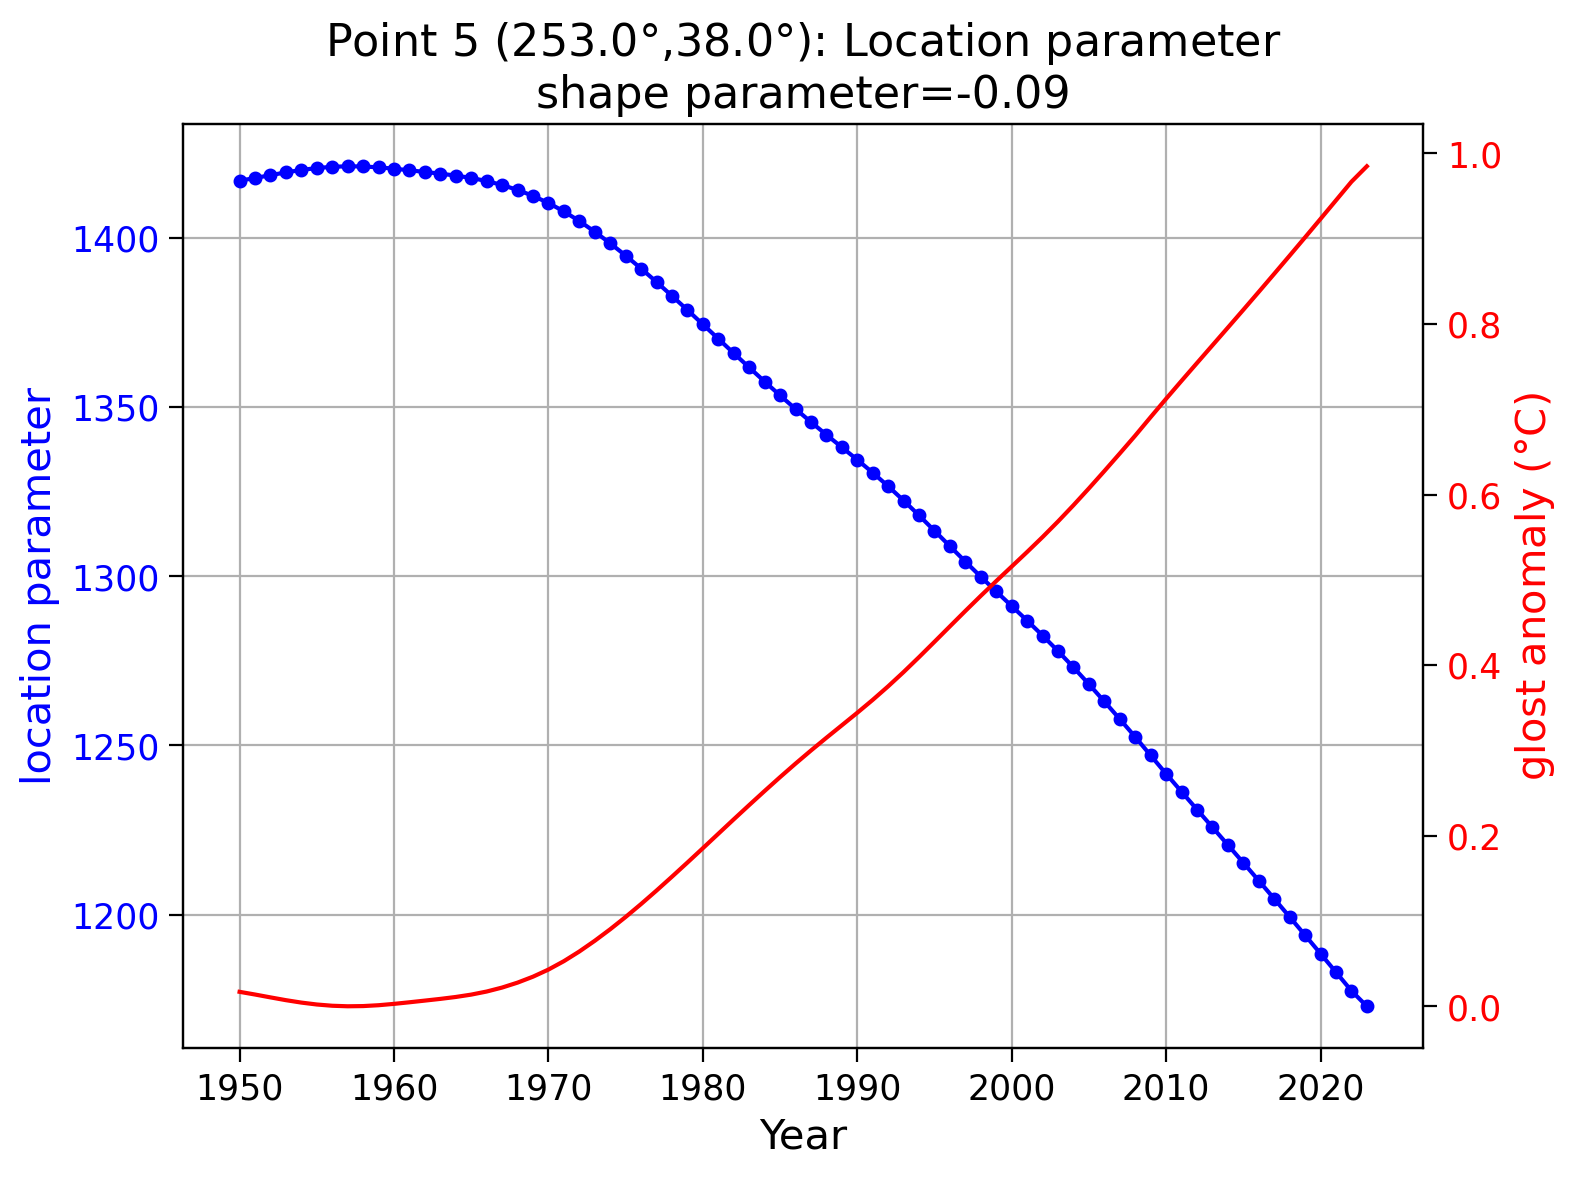

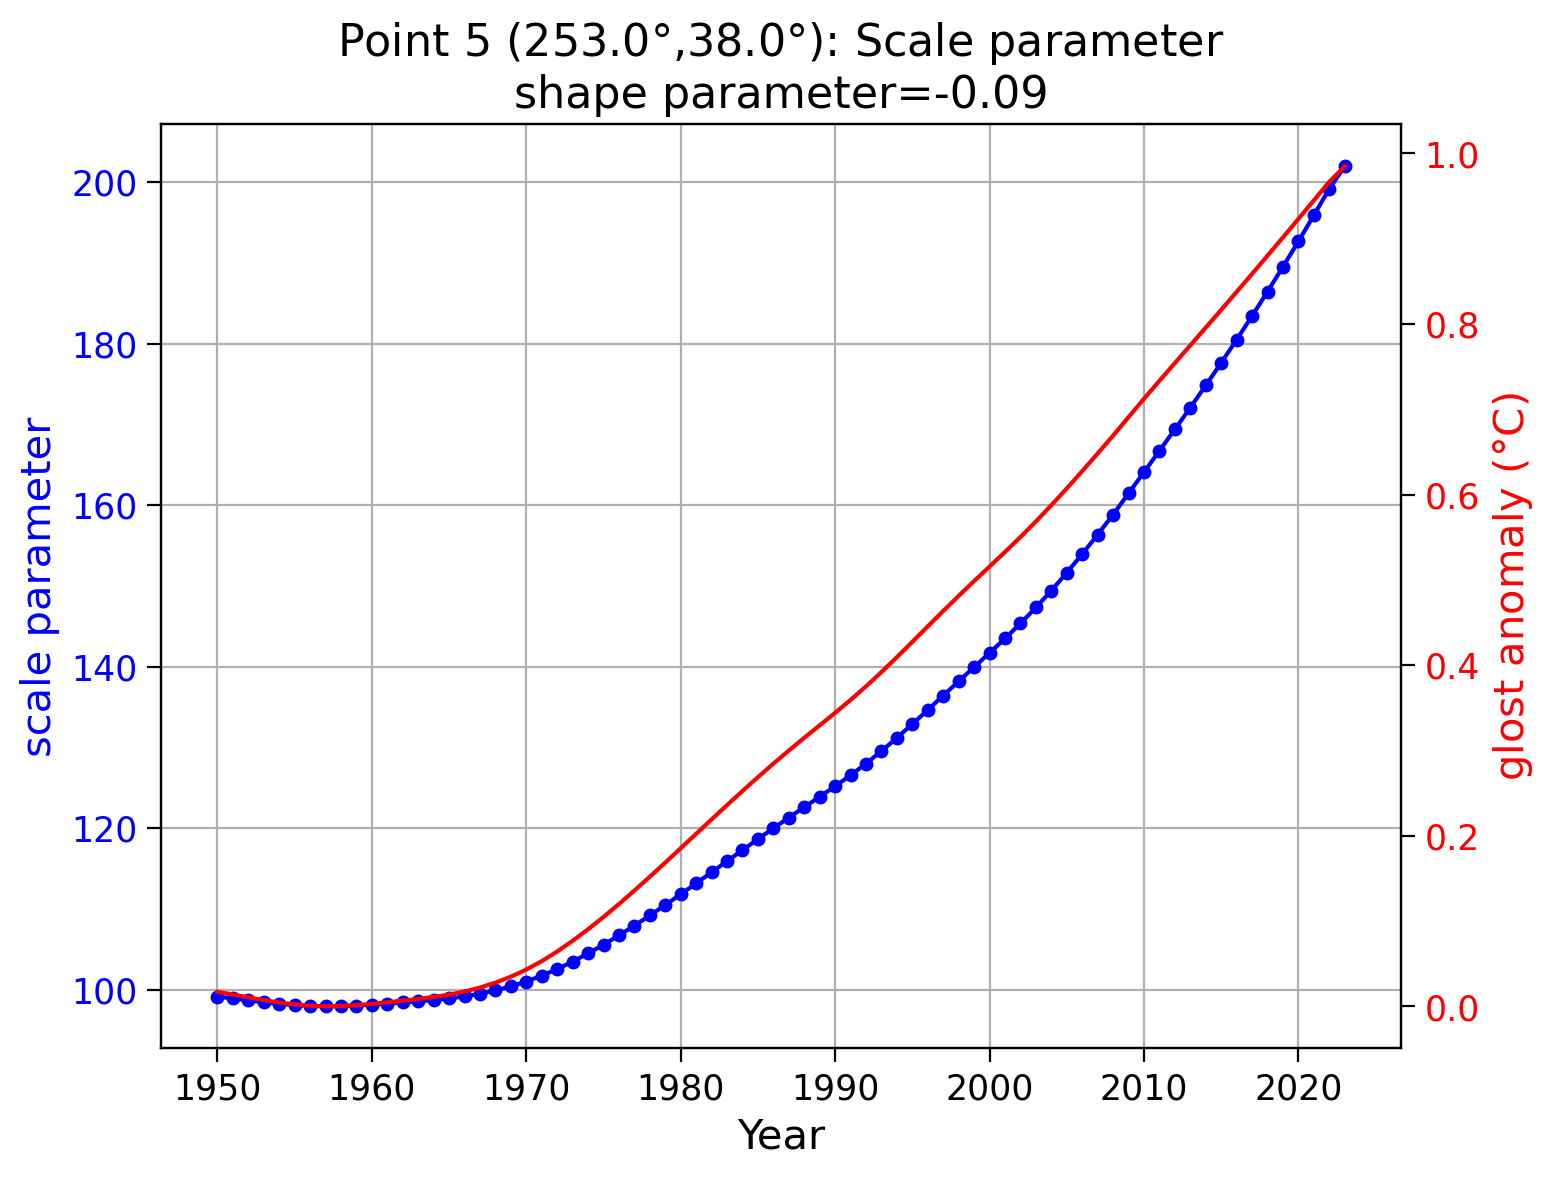

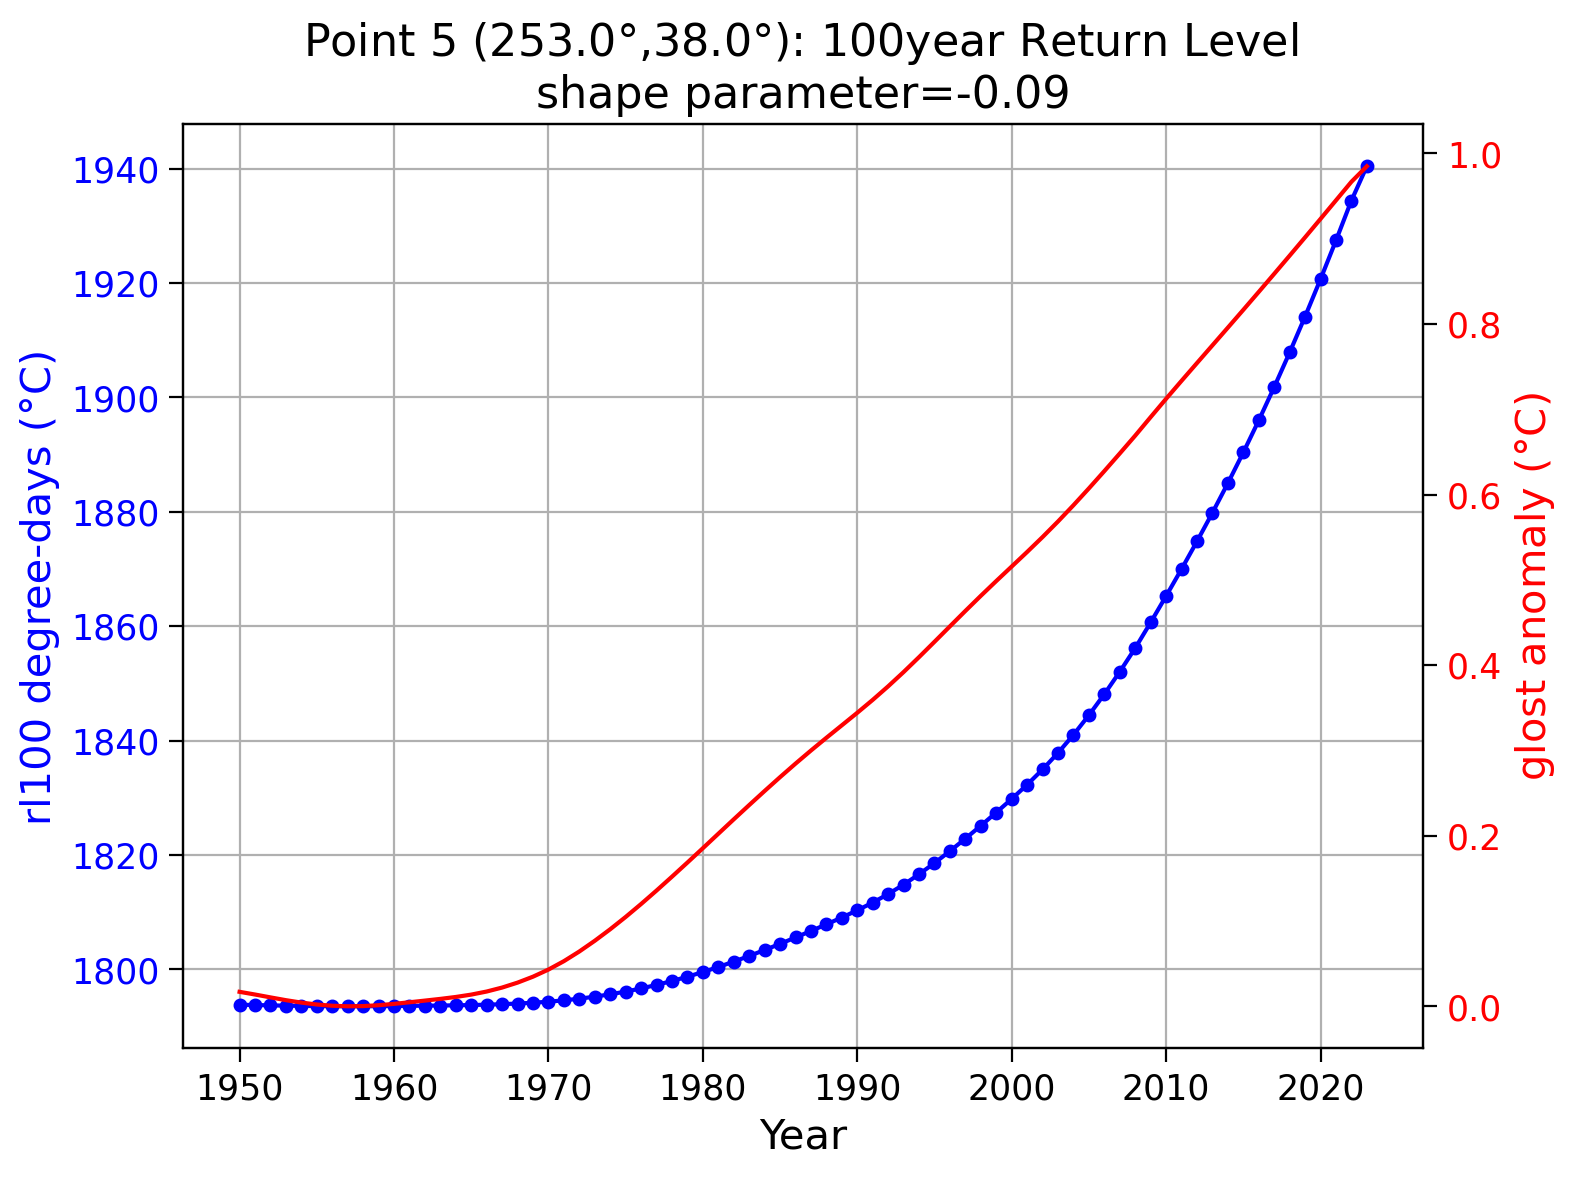

In [40]:
bins=np.arange(0,3000,50)

for ij in range(0,len(ptlon)):
  ilon=ptlon[ij]
  ilat=ptlat[ij]
  # Extract values for boxes
  dsij=ds.sel(lon=ilon,lat=ilat).load()
  df = dsij.to_dataframe()
  df = df.reset_index()
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave=df[(df['AFI'] <= 0.)|(df['AFI'].isna())]
  df = df[df['AFI'] > 0.]

  dfsave=pd.concat([dfsave, df.groupby(['lon', 'lat']).filter(lambda x: len(x) <= 49)])
  df=df.groupby(['lon', 'lat']).filter(lambda x: len(x) > 49)
  # Convert xarray to pandas DataFrame to R data.frame
  # You can now work with 'r_df' in R

  r_df = ro.conversion.py2rpy(df)
  globalenv['r_df'] = r_df

  # EVGAM model fitting  
  %R m_gev <- evgam(fmla_gev, r_df, family = "gev")
  %R gev_pred <- predict(m_gev, r_df, type = "response")
  %R gev_rl100 <- predict(m_gev, r_df, prob = 0.99)
  print('#############')
  print('#############')
  print(f'Point {ij+1}')
  print('#############')
  print('#############')
  #
  %R plot(m_gev)
  %R pp<-summary(m_gev)
  %R print(pp)
  %R -o gev_pred,pp,gev_rl100
  #
  fig, ax1 = plt.subplots()
  ax1.plot(np.arange(yearb,yeare+1,1),dsij['AFI'],color='green',marker='o',markersize=4)
  ax1.set_ylabel(f'{units}', color='green')
  ax1.tick_params(axis='y', labelcolor='green')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  #
  d1=histogram(dsij['AFI'], bins=bins, block_size=None)
  per90th=dsij['AFI'].quantile(0.95)
  per50th=dsij['AFI'].quantile(0.5)
  per10th=dsij['AFI'].quantile(0.05)
  fig, axs = plt.subplots()
  axs.bar((bins[1:]+bins[:-1])*0.5,d1.data,color='green',width=45)
  axs.axvline(per90th,color='blue', linewidth=1.5,linestyle='--', label="95th percentile" )
  axs.axvline(per50th,color='black',linewidth=1.5,linestyle='--', label="median")
  axs.axvline(per10th,color='red',  linewidth=1.5,linestyle='--', label="5th percentile" )
  axs.set_ylabel('# occurences', color='k')
  axs.grid()
  plt.legend(loc='best')
  axs.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): AFI',fontsize=16)
  #
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred['location'],color='blue',marker='o',markersize=4)
  ax1.set_ylabel(f'location parameter', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,color='red',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Location parameter\nshape parameter={gev_pred['shape'].mean():0.2f}',fontsize=16)
  #
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_pred['scale'],color='blue',marker='o',markersize=4)
  ax1.set_ylabel(f'scale parameter', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,color='red',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): Scale parameter\nshape parameter={gev_pred['shape'].mean():0.2f}',fontsize=16)
  #
  fig, ax1 = plt.subplots()
  ax2 = ax1.twinx()
  ax1.plot(np.arange(yearb,yeare+1,1),gev_rl100['q:0.99'],color='blue',marker='o',markersize=4)
  ax1.set_ylabel(f'rl100 {units}', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')
  ax2.plot(np.arange(yearb,yeare+1,1),ann_glost,color='red',label='glost anomaly')
  ax2.set_ylabel('glost anomaly ($\degree$C)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')
  ax1.set_xlabel('Year')
  ax1.grid()
  ax1.set_title(f'Point {ij+1} ({ilon:0.1f}$\degree$,{ilat:0.1f}$\degree$): 100year Return Level \nshape parameter={gev_pred['shape'].mean():0.2f}',fontsize=16)